# Trinity Admission Data Preparation <br>


The goal of this data preparation project is to ready the data for constructing a classification model to determine whether an accepted applicant will decide to attend the University, based on information collected regarding the University’s recently accepted applicants, ranging in entry term from Fall 2017, Fall 2018, Fall 2019, Fall 2020, and Fall 2021.  Your final data set should be ready for modeling. 

This script demonstrates how to clean some typical variables for the train dataset and the cleaning requiremens for all variables. 

The train dataset is a subset of the original dataset, which is used to train the model to understand the relationships between variables. Then the trained model will predict the target variable using predictors in the test dataset.

You need to handle all the columns/variables that are not processed in this scirpt following the intrsuctions in the comments.


In [ ]:
import pandas as pd
#Read in TU.csv
TU = pd.read_csv("../data/TU.csv")
pd.set_option('display.max_columns', None)
TU

In [ ]:
# Display all columns in one output
TU.columns

In [ ]:
# Divide the dataframe into training and test datasets
# In this course, you will only work on the variables in the training set
# You will need to clean the test set following the methods used in this script, when you work on modeling in later chapter.

TUtrain=TU[TU['train-test']=='train']
TUtest=TU[TU['train-test']=='test']

In [ ]:
#Column1 - ID

#Check NAs
TUtrain['ID'].isna().sum()
#No NA,so no cleaning is required. But ID will be removed in the modeling stage. Why?
# it doesn't add any information to the dataframe. It's the same as the index

In [ ]:
#Column2 - Entry Term Application

#Check NAs
print(TUtrain['Entry Term (Application)'].isna().sum())
#No NA.
TUtrain['Entry Term (Application)'].unique()
#No irregular categories.


In [ ]:
#Column 3 - Admit Type

#Check NAs
print(TUtrain['Admit Type'].isna().sum())
#No NA.
print(TUtrain['Admit Type'].unique())
#No irregular categories.

In [ ]:
#Since the data set only has first years (i.e.,only one category), 
# Admit.Type should be removed.
print(TUtrain['Admit Type'])
TUtrain=TUtrain.drop('Admit Type',axis='columns')
TUtrain.columns

In [ ]:
#Column 4 - Permanent Postal
print(TUtrain['Permanent Postal'].isna().sum())
#105 NAs.
TUtrain['Permanent Postal'].unique()
#However, the column "Permanent.Geomarket" had already provided needed information
#regarding the postal codes of different states. Therefore, this column might be
#redundant, and we might just use "Permanent.Geomarket"
#Therefore, let's remove this column and there is no need to handle the missing values
print(TUtrain['Permanent Postal'])
TUtrain=TUtrain.drop('Permanent Postal',axis='columns')
TUtrain.columns

In [ ]:
#Column 5 - Permanent Country
#0 NA.
print(TUtrain['Permanent Country'].isna().sum())
#No irregular categories.
TUtrain['Permanent Country'].unique()

In [ ]:
#Column6 - Sex
print(TUtrain['Sex'].isna().sum())
#No NA.
print(TUtrain['Sex'].unique())
#No irregular categories.


In [ ]:
#Column7 - Ethnicity
print(TUtrain['Ethnicity'].isna().sum())
#158 NAs.
print(TUtrain['Ethnicity'].unique())
#No irregular categories.
# It is fair to replace NAs with "Not Specified" as we do not have other columns for inter-field checking.
# yes it is
TUtrain['Ethnicity'].fillna("Not specified",inplace=True)
TUtrain['Ethnicity'].isna().sum()

In [ ]:
#Column8 - Race
print(TUtrain['Race'].isna().sum())
#389 NAs.
print(TUtrain['Race'].unique())

In [ ]:
#No irregular categories.
#Impute NAs with "Not specified", similar to what we do for Ethnicity.
TUtrain['Race'].fillna("Not specified", inplace=True)

In [ ]:
#The current classification of Race is too detailed, which leads to very 
#low frequencies for some categories.Let's take a look at the value frequencies.
TUtrain['Race'].value_counts()

In [ ]:
#So let's combine some of the categories because a category with a small number of cases won't have 
#a significant effect on the target variable in the modeling stage.

#Group labels with a low number of cases (< 100 cases) into "Others".
# first create a list for races with counts less than 100
races_counts =TUtrain['Race'].value_counts()
TUtrain_races_less_than_100 =races_counts[races_counts<100].index.tolist()
TUtrain_races_less_than_100

In [ ]:
TUtrain['Race'] = \
TUtrain['Race'].apply(lambda x: 'Others' if x in TUtrain_races_less_than_100 else x)
TUtrain['Race'].value_counts()

In [ ]:
#Column 9 - Religion
# print # of NAs
print(TUtrain['Religion'].isna().sum())
# print unique values for Religion
print(TUtrain['Religion'].unique())

#Impute NAs with "Not specified", similar to what we do for Race.
TUtrain['Religion'].fillna("Not specified", inplace=True)

#The current classification of Race is too detailed, which leads to very 
#low frequencies for some categories.Print the value frequencies.
TUtrain['Religion'].value_counts()


#Religion has lots of categories, with some categories having a very small number of cases. 
#Let's combine similar levels into one level( for example:['Bible Churches','Christian Reformed','Christian Scientist','Church of Christ','Church of God'] )
religion_counts = TUtrain['Religion'].value_counts()
TUtrain_religions_less_than_100 =religion_counts[religion_counts<100].index.tolist()
TUtrain_religions_less_than_100

#then combine levels with less than 100 cases into "Other" because a level accounting for lower than 1% 
#of training set is very unlikely to have a significant effect on the target variable.
TUtrain['Religion'] = \
TUtrain['Religion'].apply(lambda x: 'Others' if x in TUtrain_religions_less_than_100 else x)
TUtrain['Religion'].value_counts()
print(TUtrain['Religion'].unique())

In [ ]:
#Column 10 - First_Source Origin First Source Date
print(TUtrain['First_Source Origin First Source Date'].isna().sum())
#No NAs.

#convert to date format
TUtrain['First_Source Origin First Source Date']=\
pd.to_datetime(TUtrain['First_Source Origin First Source Date'], format='mixed')

In [ ]:
#Column11 - Inquiry Date
print(TUtrain['Inquiry Date'].isna().sum())
#3181 NAs.
frequent_inquiry = TUtrain['Inquiry Date'].value_counts().idxmax()
TUtrain['Inquiry Date'].fillna(frequent_inquiry, inplace = True)
#convert to date format
TUtrain['Inquiry Date']= pd.to_datetime(TUtrain['Inquiry Date'], errors='coerce')
print(TUtrain['Inquiry Date'].isna().sum())

In [ ]:
#Column 12 - Submitted
print(TUtrain['Submitted'].isna().sum())
#No NAs.

#convert to date format
#TUtrain['Submitted']=pd.to_datetime(TUtrain['Submitted'], errors='coerce')
TUtrain['Submitted']=pd.to_datetime(TUtrain['Submitted'], format ='mixed')

In [ ]:
#Column10-12
#After viewing Column10-12, it would be interesting to see
#whether the differences between submission date and First_Source date
#the differences between submission date and inquiry date affect the response variable.
#So let's calculate the time difference between submission date and first_source date.
TUtrain['Submit_FirstSource'] = \
(TUtrain['Submitted']-TUtrain['First_Source Origin First Source Date']).astype('timedelta64[us]')
TUtrain['Submit_Inquiry']= \
(TUtrain['Submitted']-TUtrain['Inquiry Date']).astype('timedelta64[us]')

In [ ]:
TUtrain['Submit_Inquiry']

In [ ]:
#There are NAs in Inquiry.Date, 
#thus leading to NAs in Submit_Inquiry.
#Impute NAs in Submit_Inquiry with mean.

TUtrain['Submit_Inquiry'].fillna(TUtrain['Submit_Inquiry'].mean(),inplace=True)
TUtrain['Submit_Inquiry'].isna().sum()

In [ ]:
#Remove Column10-12 after you created new variables above.   
TUtrain.drop('Inquiry Date', axis = 'columns', inplace = True)
TUtrain.drop('Submitted', axis = 'columns', inplace = True)
TUtrain.drop('First_Source Origin First Source Date', axis = 'columns', inplace = True)


In [ ]:
TUtrain.columns

In [ ]:
#Column13 - Application.Source

#Check NAs
print(TUtrain['Application Source'].isna().sum())
# 0 NAs
#Check irregular categories. If there are irregular values, you need to handle them.
#print(TUtrain['Application Source'].unique())
# CommonApp, ApplyTexas, Coalition, Select Scholar are irregulars
TUtrain['Application Source'] = TUtrain['Application Source'].replace(['CommonApp', 'ApplyTexas', 'Coalition', 'Select Scholars'], 'Other')
print(TUtrain['Application Source'].unique())

In [ ]:
#Column14 - Decision.Plan

#Check NAs
print(TUtrain['Decision Plan'].isna().sum())
# 0 NAs
#Check irregular categories. If there are irregular values, you need to handle them.
#print(TUtrain['Decision Plan'].unique())
TUtrain['Decision Plan'] = TUtrain['Decision Plan'].replace(['Early Action', 'Early Action I', 'Early Action II'], 'Early Action')
TUtrain['Decision Plan'] = TUtrain['Decision Plan'].replace(['Early Decision I', 'Early Decision II'], 'Early Decision')
print(TUtrain['Decision Plan'].unique())

In [ ]:
#Column15 - Staff.Assigned.Name
#Based on variable description, this variable might not be useful and provide
#unsightful information in the modeling.
#Also, some staffs already left Trinity.
#So remove this variable
TUtrain.drop("Staff Assigned Name", axis = "columns", inplace = True)






In [ ]:
#Column16 - Legacy
print(TUtrain['Legacy'].isna().sum())
#No NAs.
print(TUtrain['Legacy'].unique())
#No irregular categories.
#Impute NAs with "No Legacy"
TUtrain['Legacy'].fillna("No Legacy",inplace=True)
TUtrain['Legacy'].isna().sum()

#Legacy has many options, leading some options to having only a small number of cases.
#Let's group all the options into 3 categories ('Legacy',"No Legacy", "Legacy, Opt Out") 
#so that each category has the chance to affect the response variable.
TUtrain['Legacy']=\
TUtrain['Legacy'].apply(lambda x: 'Legacy, Opt Out' if x not in ['Legacy','No Legacy'] else x)
print(TUtrain['Legacy'].unique())

In [ ]:
#Column17 - Athlete
# print # NAs.
print(TUtrain['Athlete'].isna().sum())
# print unique value counts.
print(TUtrain['Athlete'].unique())

#Impute NAs with "Non-Athlete"
TUtrain['Athlete'].fillna("Non-Athlete",inplace=True)
TUtrain['Athlete'].isna().sum()

#Similar to Legacy, Athlete has many categories with a few cases.
#Group all options into three categories: 
#Athlete, Non-Athlete, and Athlete, Opt Out.
TUtrain['Athlete']=\
TUtrain['Athlete'].apply(lambda x: 'Athlete, Opt Out' if x not in ['Athlete','Non-Athlete'] else x)
print(TUtrain['Athlete'].unique())

In [ ]:
#Column18 - Sport 1 Sport

# print # NAs.
print(TUtrain['Sport 1 Sport'].isna().sum())
# print unique value counts.
print(TUtrain['Sport 1 Sport'].unique())

#Impute NAs with "No Sport"
TUtrain['Sport 1 Sport'].fillna("No Sport",inplace=True)
TUtrain['Sport 1 Sport'].isna().sum()
#Group sport men and sport women into one group
#so that each group has sufficient cases to have an impact on the response.
TUtrain['Sport 1 Sport']=\
TUtrain['Sport 1 Sport'].apply(lambda x: 'Track' if x in ['Track Men','Track Women'] else x)
TUtrain['Sport 1 Sport']=\
TUtrain['Sport 1 Sport'].apply(lambda x: 'Tennis' if x in ['Tennis Men','Tennis Women'] else x)
TUtrain['Sport 1 Sport']=\
TUtrain['Sport 1 Sport'].apply(lambda x: 'Cross Country' if x in ['Cross Country Men','Cross Country Women'] else x)
TUtrain['Sport 1 Sport']=\
TUtrain['Sport 1 Sport'].apply(lambda x: 'Soccer' if x in ['Soccer Men','Soccer Women'] else x)
TUtrain['Sport 1 Sport']=\
TUtrain['Sport 1 Sport'].apply(lambda x: 'Swimming' if x in ['Swimming Men','Swimming Women'] else x)
TUtrain['Sport 1 Sport']=\
TUtrain['Sport 1 Sport'].apply(lambda x: 'Golf' if x in ['Golf Men','Golf Women'] else x)
TUtrain['Sport 1 Sport']=\
TUtrain['Sport 1 Sport'].apply(lambda x: 'Basketball' if x in ['Basketball Men','Basketball Women'] else x)
TUtrain['Sport 1 Sport']=\
TUtrain['Sport 1 Sport'].apply(lambda x: 'Diving' if x in ['Diving Men','Diving Women'] else x)
print(TUtrain['Sport 1 Sport'].unique())

In [ ]:
print(TUtrain['Sport 1 Sport'].isna().sum())
print(TUtrain['Sport 1 Sport'].unique())

In [ ]:
#Column19 - Sport 1 Rating
# print # NAs.
print(TUtrain['Sport 1 Rating'].isna().sum())
# print unique value counts.
print(TUtrain['Sport 1 Rating'].unique())

#Impute NAs with "No Sport"
TUtrain['Sport 1 Rating'].fillna("No Sport",inplace=True)
TUtrain['Sport 1 Rating'].isna().sum()

In [ ]:
#Column20 - Sport 2 Sport

# print # NAs.
print(TUtrain['Sport 2 Sport'].isna().sum())
# print unique value counts.
print(TUtrain['Sport 2 Sport'].unique())

#impute NAs with "No 2ndSport".
TUtrain['Sport 2 Sport'].fillna("No 2ndSport",inplace=True)
TUtrain['Sport 2 Sport'].isna().sum()
#The number of cases for each sport type is very small (< about 1% of the data set).
#It's better to group all options into 2 categories: 2ndSport vs. No 2ndSport.
TUtrain['Sport 2 Sport']=\
TUtrain['Sport 2 Sport'].apply(lambda x: '2ndSport' if x != 'No 2ndSport' else x)
print(TUtrain['Sport 2 Sport'].unique())

In [ ]:
#Column21 - Sport 2 Rating
print(TUtrain['Sport 2 Rating'].isna().sum())
#9957 NAs.
print(TUtrain['Sport 2 Rating'].unique())
#Only 43 out of 10000 observations are rated, which is less than 0.5% of the data set!
#Sport.2.Rating will not have much impact on the target.
#Remove it in the modeling stage.

TUtrain.drop('Sport 2 Rating',axis='columns', inplace=True)

In [ ]:
#Column22 - Sport 3 Sport

# print # NAs.
print(TUtrain['Sport 3 Sport'].isna().sum())
# print unique value counts.
print(TUtrain['Sport 3 Sport'].unique())
#impute NAs with "No 3rdSport".
TUtrain['Sport 3 Sport'].fillna("No 3rdSport",inplace=True)
TUtrain['Sport 3 Sport'].isna().sum()


#The number of cases for each sport type is very small (< 0.5% of the data set).
#It's better to group all options into 2 categories: 3rdSport vs. No 3rdSport.
TUtrain['Sport 3 Sport']=\
TUtrain['Sport 3 Sport'].apply(lambda x: '3rdSport' if x != 'No 3rdSport' else x)
print(TUtrain['Sport 3 Sport'].unique())

In [ ]:
#Column23 - Sport.3.Rating

print(TUtrain['Sport 3 Rating'].isna().sum())
#9998 NAs.
print(TUtrain['Sport 3 Rating'].unique())
#No questionable category.
#Only 2 out of 10000 observations are rated, which will not provide much insightful
#information. Therefore,remove this column
TUtrain.drop('Sport 3 Rating',axis='columns', inplace=True)


In [ ]:
#Column24 - Academic Interest 1

#check NAs
print(TUtrain['Academic Interest 1'].isna().sum())
# 4 NAs.
print(TUtrain['Academic Interest 1'].unique())



In [ ]:
# Step1: Most of the NAs for Academic.Interest.1 have a value for Academic.Interest.2
#We may assign the corresponding values in Academic.Interest.2 
#to NAs in Academic.Interest.1 if Academic.Interest.2 has a value.

# When update values in a subset of dataframes, 
# Try using .loc[row_indexer,col_indexer] = value instead to avoid chained indexing issue

for index,row in TUtrain.iterrows():
    if pd.isna(row['Academic Interest 1']):
        #print(index,row['Academic Interest 1'],row['Academic Interest 2'])
        TUtrain.loc[index,'Academic Interest 1']=TUtrain.loc[index,'Academic Interest 2']

In [ ]:
    
# Step2:For the remaining NAs in Academic.Interest.1, assign Undecided.
TUtrain['Academic Interest 1'].fillna('Undecided',inplace=True)
TUtrain['Academic Interest 1'].unique()

In [ ]:

#  Step3: Group Business related options into "Business".
# find all business related labels and group them into business
TUtrain['Academic Interest 1'] = \
TUtrain['Academic Interest 1'].apply(lambda x: 'Business' if x in['Finance', 'Business - Communication Management', 'Economics', 'Business - Accounting', 'Entrepreneurship', 'Mathematical Finance', 'Business - Sport Management', 'Business - Management', 'Business - Marketing', 'Business - International Business', 'Business Analytics & Technology', 'Business - Management Information Systems', 'Business Legal Studies', ] else x)



# step 4: Group majors with a low number of cases (< 100 cases) into "Others".
# first create a list for majors with counts less than 100
academic_interest_counts = TUtrain['Academic Interest 1'].value_counts()
TUtrain_low_count_majors = academic_interest_counts[academic_interest_counts < 100].index.tolist()
TUtrain['Academic Interest 1'] = \
TUtrain['Academic Interest 1'].apply(lambda x: 'Others' if x in TUtrain_low_count_majors else x)
TUtrain['Academic Interest 1'].value_counts()



In [ ]:
#Column25 - Academic.Interest.2

#Check NAs
print(TUtrain['Academic Interest 2'].isna().sum())


#Replace repeated academic interest 2 with Undecided, which means academic interest 2==academic interest 1
for index,row in TUtrain.iterrows():
    if pd.isna(row['Academic Interest 2']):
        #print(index,row['Academic Interest 1'],row['Academic Interest 2'])
        TUtrain.loc[index,'Academic Interest 2']=TUtrain.loc[index,'Academic Interest 1']


#then replace NAs Undecided
TUtrain['Academic Interest 2'].fillna('Undecided',inplace=True)
TUtrain['Academic Interest 2'].unique()


#Group Business related options into "Business".
TUtrain['Academic Interest 2'] = \
TUtrain['Academic Interest 2'].apply(lambda x: 'Business' if x in['Finance', 'Business - Communication Management', 'Economics', 'Business - Accounting', 'Entrepreneurship', 'Mathematical Finance', 'Business - Sport Management', 'Business - Management', 'Business - Marketing', 'Business - International Business', 'Business Analytics & Technology', 'Business - Management Information Systems', 'Business Legal Studies', ] else x)


#Group options with a low number of cases (< 100 cases) into "Others".
academic_interest_counts2 = TUtrain['Academic Interest 1'].value_counts()
TUtrain_low_count_majors2 = academic_interest_counts2[academic_interest_counts2 < 100].index.tolist()
TUtrain['Academic Interest 1'] = \
TUtrain['Academic Interest 1'].apply(lambda x: 'Others' if x in TUtrain_low_count_majors2 else x)
TUtrain['Academic Interest 1'].value_counts()


In [ ]:
#Column26 - First_Source Origin First Source Summary

# print # NAs.
print(TUtrain['First_Source Origin First Source Summary'].isna().sum())
# print unique value counts.
print(TUtrain['First_Source Origin First Source Summary'].unique())
#Similar to Academic.Interest.2, group options with a low number of cases (< 100) into "Other Sources".
First_Source = TUtrain['First_Source Origin First Source Summary'].value_counts()
TUtrain_low_count = First_Source[First_Source < 100].index.tolist()
TUtrain['Academic Interest 1'] = \
TUtrain['Academic Interest 1'].apply(lambda x: 'Others' if x in TUtrain_low_count else x)
TUtrain['Academic Interest 1'].value_counts()

In [ ]:
#Column27 - Total Event Participation


#Check NAs.
print(TUtrain['Total Event Participation'].isna().sum())

#check irregular values
print(TUtrain['Total Event Participation'].unique())

#3, 4, 5 combined accounts for < 1% of the data set.
#Compared to the number of cases in 0, 1, and 2, the number of cases
#in 3, 4, and 5 won't be very useful in predicting the response.
#So group 3, 4, and 5 into "2 or more".
TUtrain['Total Event Participation'] = \
TUtrain['Total Event Participation'].apply(lambda x: '2 or more' if x in [3, 4, 5] else x)
print(TUtrain['Total Event Participation'].unique())

In [ ]:
#Column28 - Count of Campus Visits

# print # NAs.
print(TUtrain['Count of Campus Visits'].isna().sum())
# print unique value counts.
print(TUtrain['Count of Campus Visits'].unique())
# group 5, 6, and 8 into '4 or more'.
TUtrain['Count of Campus Visits'] = \
TUtrain['Count of Campus Visits'].apply(lambda x: '4 or more' if x in [4, 5, 6, 8] else x)
print(TUtrain['Count of Campus Visits'].unique())


In [ ]:
#Column29 - School #1 Organization Category
print(TUtrain['School #1 Organization Category'].isna().sum())
#25  NAs.
print(TUtrain['School #1 Organization Category'].value_counts())
#Only 8 cases belong to College but 9967 cases belong to High School.
#Remove this variable.
TUtrain.drop('School #1 Organization Category', axis='columns', inplace=True)

In [ ]:
#Column30 - School 1 Code
print(TUtrain['School 1 Code'].isna().sum())
#7842 NAs.
print(TUtrain['School 1 Code'].unique())
#School Code will not matter much to produce insightful information.
#Additionally, there are 7842 missing values.
#so remove this column in the modeling stage.
TUtrain.drop('School 1 Code', axis='columns', inplace=True)

In [ ]:
#Column31 - School 1 Class Rank (Numeric)
print(TU.loc[TU['train-test']=='train','School 1 Class Rank (Numeric)'].isna().sum())
#5357 NAs.

In [ ]:
# Column32 - School 1 Class Size (Numeric)

print(TUtrain['School 1 Class Size (Numeric)'].isna().sum())

#5357 NAs.
#Percentage rank can more accurately reflect a student's academic performance than numeric rank. 

#Create a New Column - School 1 Top Percent in Class

TUtrain['School 1 Top Percent in Class'] =\
100 *(TUtrain['School 1 Class Rank (Numeric)']/TUtrain['School 1 Class Size (Numeric)'])


TUtrain['School 1 Top Percent in Class'].isna().sum()

In [ ]:
# #Impute the 5357 NAs based on Academic.Index column. 

# #Since we need to handle NAs in School 1 Top Percent in Class
# according to Academic.Index, first let's see whether Academic Index needs to be cleaned.
print(TUtrain['Academic Index'].isna().sum())
#829 NAs.
print(TUtrain['Academic Index'].value_counts())
#No questionable level.
#Impute 829 NAs with the most common level.
TUtrain['Academic Index'].fillna(3,inplace=True)
TUtrain['Academic Index'].unique()
#No missing values in Academic Index now.

In [ ]:
#calculate school 1 top percent in class for each academic index group
grouped=TUtrain.groupby('Academic Index')
grouped
average=grouped.mean('School 1 Top Percent in Class')
average['School 1 Top Percent in Class']

In [ ]:
#Impute missing values in 'School 1 Top Percent in Class' based on Academic Index group average
for i,row in TUtrain.iterrows():

    if (row['Academic Index']== 1.0) & (pd.isna(row['School 1 Top Percent in Class'])):
        TUtrain.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][1.0]
    elif (row['Academic Index']== 2.0) & (pd.isna(row['School 1 Top Percent in Class'])):
            TUtrain.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][2.0]
    elif (row['Academic Index']== 3.0) & (pd.isna(row['School 1 Top Percent in Class'])):
            TUtrain.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][3.0]
    elif (row['Academic Index']== 4.0) & (pd.isna(row['School 1 Top Percent in Class'])):
            TUtrain.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][4.0]
    elif (row['Academic Index']== 5.0) & (pd.isna(row['School 1 Top Percent in Class'])):
            TUtrain.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][5.0]
print(TUtrain['Academic Index'].isna().sum())

In [ ]:
#Column33 - School 1 GPA

#Remove this variable in the modeling stage
#because School.1.GPA.Recalculated is more accurate.
TUtrain.drop('School 1 GPA', axis='columns', inplace=True)




In [ ]:
#Column34 - School 1 GPA Scale
#Remove this variable in the modeling stage as it is irrelevant.
TUtrain.drop('School 1 GPA Scale', axis='columns', inplace=True)




In [ ]:
#Column35 - School 1 GPA Recalculated

#Check NAs

print(TUtrain['School 1 GPA Recalculated'].isna().sum())
#0 NAs.

TUtrain['School 1 GPA Recalculated'].skew()
#Check skewness

# if the skewness score is below -1 or above 1, the variable is high skewed
#if the skewness score is positive, it means it is right tail skew
# if the skewness score is negative, it means it is left tail skew
#Since it is moderately skewed, and it is understandable for the left skewness as 
#a lot of students got into Trinity with a high GPA (almost 4.0), it is unnecessary to do transformation.
# Some modeling methods requires variables following a normal distribution, therefore you need to transform the skewed data
# before inputting it into the model, such as liner regression analysis.

In [ ]:
#Column36 - School 2 Class Rank (Numeric)
#Check NAs
print(TUtrain['School 2 Class Rank (Numeric)'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because, percentage rank can more accurately reflect a student's academic performance than numeric rank.
TUtrain.drop('School 2 Class Rank (Numeric)', axis='columns', inplace=True)

In [ ]:
#Column37 - School 2 Class Size (Numeric)

#Check NAs
print(TUtrain['School 2 Class Size (Numeric)'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because, percentage rank can more accurately reflect a student's academic performance than numeric rank.
TUtrain.drop('School 2 Class Size (Numeric)', axis='columns', inplace=True)

In [ ]:
#Column38 - School 2 GPA

#Check NAs
print(TUtrain['School 2 GPA'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because school 2 gpa recalculated is more accurate
TUtrain.drop('School 2 GPA', axis='columns', inplace=True)

In [ ]:
#Column39 - School 2 GPA Scale
#Check NAs
print(TUtrain['School 2 GPA Scale'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# we can remove it because it is irrelevant in the modeling stage
TUtrain.drop('School 2 GPA Scale', axis='columns', inplace=True)

In [ ]:
#Column40 - School 2 GPA Recalculated
#Check NAs
print(TUtrain['School 2 GPA Recalculated'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because, it is irrelevant in the modeling stage
TUtrain.drop('School 2 GPA Recalculated', axis='columns', inplace=True)

In [ ]:
#Column41 - School 3 Class Rank (Numeric)
#Check NAs
print(TUtrain['School 3 Class Rank (Numeric)'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because, percentage rank can more accurately reflect a student's academic performance than numeric rank.
TUtrain.drop('School 3 Class Rank (Numeric)', axis='columns', inplace=True)

In [ ]:
#Column42 - School 3 Class Size (Numeric)
#Check NAs
print(TUtrain['School 3 Class Size (Numeric)'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove becasue it is irrelevant in the modeling stage
TUtrain.drop('School 3 Class Size (Numeric)', axis='columns', inplace=True)

In [ ]:
#Column43 - School 3 GPA
#Check NAs
print(TUtrain['School 3 GPA'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because school 2 gpa recalculated is more accurate
TUtrain.drop('School 3 GPA', axis='columns', inplace=True)

In [ ]:
#Column44 - School 3 GPA Scale
#Check NAs
print(TUtrain['School 3 GPA Scale'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# we can remove it because it is irrelevant in the modeling stage
TUtrain.drop('School 3 GPA Scale', axis='columns', inplace=True)

In [ ]:
#Column45 - School 3 GPA Recalculated
#Check NAs
print(TUtrain['School 3 GPA Recalculated'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because it is irrelevant in the modelin stage
TUtrain.drop('School 3 GPA Recalculated', axis='columns', inplace=True)

In [ ]:
#Column46 ACT Composite

# print # NAs.
print(TUtrain['ACT Composite'].isna().sum())
# print unique value counts.
print(TUtrain['ACT Composite'].unique())
#Replace missing ACT scores with SAT Concordance scores. 
#Convert 'SAT R Evidence-Based Reading and Writing Section + Math Section scores' into ACT based on the ACT-SAT concordance table pdf;
#Hint: create a dictionary to convert SAT into ACT
sat_to_act = {
    range(1570, 1601): 36, range(1530, 1570): 35, range(1490, 1530): 34,
    range(1450, 1490): 33, range(1420, 1450): 32, range(1390, 1420): 31,
    range(1360, 1390): 30, range(1330, 1360): 29, range(1300, 1330): 28,
    range(1260, 1300): 27, range(1230, 1260): 26, range(1200, 1230): 25,
    range(1160, 1200): 24, range(1130, 1160): 23, range(1100, 1130): 22,
    range(1060, 1100): 21, range(1030, 1060): 20, range(990, 1030): 19,
    range(960, 990): 18, range(920, 960): 17, range(880, 920): 16,
    range(830, 880): 15, range(780, 830): 14, range(730, 780): 13,
    range(690, 730): 12, range(650, 690): 11, range(620, 650): 10,
    range(590, 620): 9
}

def convert_sat_to_act(sat_score):
    if pd.notna(sat_score):  # Ensure SAT score is not NaN
        for sat_range, act_score in sat_to_act.items():
            if int(sat_score) in sat_range:
                return act_score
    return None

TUtrain.loc[TUtrain['ACT Composite'].isna(), 'ACT Composite'] = TUtrain['SAT R Evidence-Based Reading and Writing Section + Math Section'].apply(convert_sat_to_act)
#Third, impute the rest missing ACTs with the mean of ACTs.
mean_act = TUtrain['ACT Composite'].mean()
TUtrain['ACT Composite'].fillna(mean_act, inplace=True)





In [ ]:
#Column47 ACT English

#Check NAs 
print(TUtrain['ACT English'].isna().sum())
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtrain.drop('ACT English', axis='columns', inplace=True)

In [ ]:
#Column48 ACT Reading
#Check NAs 
print(TUtrain['ACT Reading'].isna().sum())
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtrain.drop('ACT Reading', axis='columns', inplace=True)

In [ ]:
#Column50 ACT Math
#Check NAs 
print(TUtrain['ACT Math'].isna().sum())

# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtrain.drop('ACT Math', axis='columns', inplace=True)

In [ ]:
#Column51 ACT Science Reasoning
#Check NAs 
print(TUtrain['ACT Science Reasoning'].isna().sum())



# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtrain.drop('ACT Science Reasoning', axis='columns', inplace=True)

In [ ]:
#Column52 ACT Writing
#??? NAs 
print(TUtrain['ACT Writing'].isna().sum())
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtrain.drop('ACT Writing', axis='columns', inplace=True)

In [ ]:
#Column53 SAT I CR + M
#Check NAs 
print(TUtrain['SAT I CR + M'].isna().sum())


# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtrain.drop('SAT I CR + M', axis='columns', inplace=True)

In [ ]:
#Column54 SAT R Evidence-Based Reading and Writing Section + Math Section
print(TUtrain['SAT R Evidence-Based Reading and Writing Section + Math Section'].isna().sum())


# This column is used to generate ATC concordance scores.
# No further processing needed.

In [ ]:
#Column55 Permanent Geomarket
#First, replace the missing values with the most frequent geo market value.
most_frequent_values=TUtrain['Permanent Geomarket'].value_counts().idxmax()
TUtrain['Permanent Geomarket'].fillna(most_frequent_values, inplace=True)
TUtrain['Permanent Geomarket']
#Second, group geomarket values into different regions. Refer to the region .csv for grouping.
TUtrain[['State', 'GeomarketID']] = TUtrain['Permanent Geomarket'].str.split('-', expand = True)

# create dictionary
region_id = dict()

# create groups
region_id[('AL')] = 'South, East South Central'
region_id[('AK', 'CA', 'HI', 'OR', 'WA')] = 'West, Pacific'
region_id[('AZ')] = 'West, Mountain'
region_id[('AR', 'LA', 'OK', 'TX')] = 'South, West South Central'
region_id[('CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY')] = 'West, Mountain'
region_id[('CT', 'ME', 'MA', 'NH', 'RI', 'VT')] = 'Northeast, New England'
region_id[('DE', 'DC', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV')] = 'South, South Atlantic'
region_id[('IL', 'IN', 'MI', 'OH')] = 'Midwest, East North Central'
region_id[('IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD', 'WI')] = 'Midwest, West North Central'
region_id[('KY', 'MS', 'TN')] = 'South, East South Central'
region_id[('NJ', 'NY', 'PA')] = 'Northeast, Middle Atlantic'

# not a US state
region_id[('INT')] = 'International'
region_id[('US')] = 'United States'
region_id[('PR')] = 'Puerto Rico'

# define function to return groups in dictionary to a new column
def get_region(state):
    for key in region_id.keys():
        if state in key:
            return region_id[key]
            break

# use function to create new column
#TUtrain['Region'] = TUtrain['State'].apply(get_region)
TUtrain['Permanent Geomarket'] = TUtrain['State'].apply(get_region)

TUtrain['Permanent Geomarket'].unique()

TUtrain.drop('State', axis='columns', inplace=True)
TUtrain.drop('GeomarketID', axis='columns', inplace=True)

In [ ]:
#Column56 Citizenship Status
print(TUtrain['Citizenship Status'].isna().sum())
# This column is used for inter-field checking so keep it

In [ ]:
#Column57 Academic Index
print(TUtrain['Academic Index'].isna().sum())
# This column is used for inter-field checking so keep it

In [ ]:
#Column58 Intend to Apply for Financial Aid?
print(TUtrain['Intend to Apply for Financial Aid?'].isna().sum())
#Handling missing values. Justify your choice.
TUtrain['Intend to Apply for Financial Aid?'].fillna(0, inplace=True)
TUtrain['Intend to Apply for Financial Aid?']
# if they didn't clarify whether they intended to apply for financial aid, it should be assumed they do not intend to apply

In [ ]:
#Column59 Merit Award

#Refer to the Merit Award Code.csv for grouping. 
#Recategorize all the levels into fewer levels, Justify your grouping policy in comments
merit_awards = dict()

# set to a group
merit_awards[('I10', 'I5', 'I9')] = 'International Student Scholarship ($5,000 - $10,000)'
merit_awards[('I12', 'I12.5', 'I15', 'I17', 'I18', 'I19', 'I20', )] = 'International Student Scholarship ($11,000 - $20,000)'
merit_awards[('I21', 'I24', 'I25', 'I26', 'I27', 'I28', 'I30')] = 'International Student Scholarship ($21,000 - $30,000)'
merit_awards[('I32', 'I33', 'I35', 'I38')] = 'International Student Scholarship ($31,000 - $38,000)'
merit_awards[('D12.5')] = "Dean's Merit Award"
merit_awards[('Z0', 'I0')] = 'No Merit'
merit_awards[('M24')] = 'Murchison Merit Award'
merit_awards[('P17')] = "President's Merit Award"
merit_awards[('SEM')] = 'Full Ride, Semmes Scholar'
merit_awards[('TT9')] = 'Trinity Tiger Award'
merit_awards[('TTS')] = 'Trinity Tower Scholar'
merit_awards[('T21')] = "Trustee's Merit Award"
merit_awards[('X0')] = 'Tuition Exchange'
merit_awards[('Y0')] = 'Tuition Remission'

# define function to apply Merit Award column for groupings
def get_merit_award(scholar_code):
    for key, category in merit_awards.items():
        if scholar_code in key:
            return category
    return 'No award'

TUtrain['Merit Award'] = TUtrain['Merit Award'].apply(get_merit_award)

TUtrain['Merit Award'].unique()



In [ ]:
#Column60 SAT Concordance Score (of SAT R)
TUtrain.drop('SAT Concordance Score (of SAT R)', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# SAT R Evidence-Based Reading and Writing Section + Math Section is used to generate ACT Concordance Scores so this column is redundant

In [ ]:
#Column61 ACT Concordance Score (of SAT R)
TUtrain.drop('ACT Concordance Score (of SAT R)', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column62 ACT Concordance Score (of SAT)
TUtrain.drop('ACT Concordance Score (of SAT)', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column63 Test Optional
TUtrain.drop('Test Optional', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column64 SAT I Critical Reading
TUtrain.drop('SAT I Critical Reading', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column65 SAT I Math
TUtrain.drop('SAT I Math', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column66 SAT I Writing
TUtrain.drop('SAT I Writing', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column67 SAT R Evidence-Based Reading and Writing Section
TUtrain.drop('SAT R Evidence-Based Reading and Writing Section', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column68 SAT R Math Section
TUtrain.drop('SAT R Math Section', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column69 Decision
print(TUtrain['Decision'].isna().sum())
# This would be your dependent variable in the classification model so keep it.

In [ ]:
# After you clean all variables, output the cleaned dataframe to a csv file
# the csv file can be found in your current working directory


TUtrain.to_csv('../data/cleaneddftrain.csv')

In [ ]:
# Compare the your table structure with the screenshot in the submission box
# Make sure all primary predictors and target variables do not have any missing values and only have
# regualr and correct values.

TUtrain.info()

## Test Cleaning

In [ ]:
#Column1 - ID

#Check NAs
TUtest['ID'].isna().sum()
#No NA,so no cleaning is required. But ID will be removed in the modeling stage. Why?
# it doesn't add any information to the dataframe. It's the same as the index

In [ ]:
#Column2 - Entry Term Application

#Check NAs
print(TUtest['Entry Term (Application)'].isna().sum())
#No NA.
TUtest['Entry Term (Application)'].unique()
#No irregular categories.


In [ ]:
#Column 3 - Admit Type

#Check NAs
print(TUtest['Admit Type'].isna().sum())
#No NA.
print(TUtest['Admit Type'].unique())
#No irregular categories.

In [ ]:
#Since the data set only has first years (i.e.,only one category), 
# Admit.Type should be removed.
print(TUtest['Admit Type'])
TUtest=TUtest.drop('Admit Type',axis='columns')
TUtest.columns

In [ ]:
#Column 4 - Permanent Postal
print(TUtest['Permanent Postal'].isna().sum())
#105 NAs.
TUtest['Permanent Postal'].unique()
#However, the column "Permanent.Geomarket" had already provided needed information
#regarding the postal codes of different states. Therefore, this column might be
#redundant, and we might just use "Permanent.Geomarket"
#Therefore, let's remove this column and there is no need to handle the missing values
print(TUtest['Permanent Postal'])
TUtest=TUtest.drop('Permanent Postal',axis='columns')
TUtest.columns

In [ ]:
#Column 5 - Permanent Country
#0 NA.
print(TUtest['Permanent Country'].isna().sum())
print(TUtest['Permanent Country'].unique()) #No irregular categories.
# null
null_PC = TUtest[TUtest['Permanent Country'].isna()]
print(null_PC)
# fill na (citizenship was US so imputing with United States
TUtest['Permanent Country'].fillna('United States', inplace = True)

print(TUtest['Permanent Country'].isna().sum())

In [ ]:
#Column6 - Sex
print(TUtest['Sex'].isna().sum())
#No NA.
print(TUtest['Sex'].unique())
#No irregular categories.


In [ ]:
#Column7 - Ethnicity
print(TUtest['Ethnicity'].isna().sum())
#158 NAs.
print(TUtest['Ethnicity'].unique())
#No irregular categories.
# It is fair to replace NAs with "Not Specified" as we do not have other columns for inter-field checking.
# yes it is
TUtest['Ethnicity'].fillna("Not specified",inplace=True)
TUtest['Ethnicity'].isna().sum()

In [ ]:
#Column8 - Race
print(TUtest['Race'].isna().sum())
#389 NAs.
print(TUtest['Race'].unique())

In [ ]:
#No irregular categories.
#Impute NAs with "Not specified", similar to what we do for Ethnicity.
TUtest['Race'].fillna("Not specified", inplace=True)

In [ ]:
#The current classification of Race is too detailed, which leads to very 
#low frequencies for some categories.Let's take a look at the value frequencies.
TUtest['Race'].value_counts()

In [ ]:
#So let's combine some of the categories because a category with a small number of cases won't have 
#a significant effect on the target variable in the modeling stage.

#Group labels with a low number of cases (< 100 cases) into "Others".
# first create a list for races with counts less than 100
races_counts =TUtest['Race'].value_counts()
races_less_than_100 =races_counts[races_counts<100].index.tolist()
races_less_than_100

In [ ]:
# Use list from train dataset to clean and impute TUtest
TUtrain_races_less_than_100.append('Asian, Black or African American, Native Hawaiian or Other Pacific, White')
TUtrain_races_less_than_100.append('American Indian or Alaska Native, Asian, Black or African American, Native Hawaiian or Other Pacific, White')
TUtrain_races_less_than_100.append('Black or African American, Native Hawaiian or Other Pacific, White')
TUtest['Race'] = \
TUtest['Race'].apply(lambda x: 'Others' if x in TUtrain_races_less_than_100 else x)
TUtest['Race'].value_counts()

In [ ]:
#Column 9 - Religion
# print # of NAs
print(TUtest['Religion'].isna().sum())
# print unique values for Religion
print(TUtest['Religion'].unique())

#Impute NAs with "Not specified", similar to what we do for Race.
TUtest['Religion'].fillna("Not specified", inplace=True)

#The current classification of Race is too detailed, which leads to very 
#low frequencies for some categories.Print the value frequencies.
TUtest['Religion'].value_counts()


#Religion has lots of categories, with some categories having a very small number of cases. 
#Let's combine similar levels into one level( for example:['Bible Churches','Christian Reformed','Christian Scientist','Church of Christ','Church of God'] )
religion_counts = TUtest['Religion'].value_counts()
religions_less_than_100 =religion_counts[religion_counts<100].index.tolist()
religions_less_than_100

#then combine levels with less than 100 cases into "Other" because a level accounting for lower than 1% 
#of training set is very unlikely to have a significant effect on the target variable.
TUtrain_religions_less_than_100.append('Independent')
TUtrain_religions_less_than_100.append('Church of the Nazarene')
TUtest['Religion'] = \
TUtest['Religion'].apply(lambda x: 'Others' if x in TUtrain_religions_less_than_100 else x)
TUtest['Religion'].value_counts()
print(TUtest['Religion'].unique())

In [ ]:
#Column 10 - First_Source Origin First Source Date
print(TUtest['First_Source Origin First Source Date'].isna().sum())
#No NAs.

#convert to date format
TUtest['First_Source Origin First Source Date']=\
pd.to_datetime(TUtest['First_Source Origin First Source Date'], format='mixed')

In [ ]:
#Column11 - Inquiry Date
print(TUtest['Inquiry Date'].isna().sum())
#3181 NAs.
frequent_inquiry = TUtest['Inquiry Date'].value_counts().idxmax()
TUtest['Inquiry Date'].fillna(frequent_inquiry, inplace = True)
#convert to date format
TUtest['Inquiry Date']= pd.to_datetime(TUtest['Inquiry Date'], errors='coerce')
print(TUtest['Inquiry Date'].isna().sum())

In [ ]:
#Column 12 - Submitted
print(TUtest['Submitted'].isna().sum())
#No NAs.

#convert to date format
#TUtest['Submitted']=pd.to_datetime(TUtest['Submitted'], errors='coerce')
TUtest['Submitted']=pd.to_datetime(TUtest['Submitted'], format ='mixed')

In [ ]:
#Column10-12
#After viewing Column10-12, it would be interesting to see
#whether the differences between submission date and First_Source date
#the differences between submission date and inquiry date affect the response variable.
#So let's calculate the time difference between submission date and first_source date.
TUtest['Submit_FirstSource'] = \
(TUtest['Submitted']-TUtest['First_Source Origin First Source Date']).astype('timedelta64[us]')
TUtest['Submit_Inquiry']= \
(TUtest['Submitted']-TUtest['Inquiry Date']).astype('timedelta64[us]')

In [ ]:
TUtest['Submit_Inquiry']

In [ ]:
#There are NAs in Inquiry.Date, 
#thus leading to NAs in Submit_Inquiry.
#Impute NAs in Submit_Inquiry with mean.

TUtest['Submit_Inquiry'].fillna(TUtest['Submit_Inquiry'].mean(),inplace=True)
TUtest['Submit_Inquiry'].isna().sum()

In [ ]:
#Remove Column10-12 after you created new variables above.   
TUtest.drop('Inquiry Date', axis = 'columns', inplace = True)
TUtest.drop('Submitted', axis = 'columns', inplace = True)
TUtest.drop('First_Source Origin First Source Date', axis = 'columns', inplace = True)


In [ ]:
TUtest.columns

In [ ]:
#Column13 - Application.Source

#Check NAs
print(TUtest['Application Source'].isna().sum())
# 0 NAs
#Check irregular categories. If there are irregular values, you need to handle them.
#print(TUtest['Application Source'].unique())
# CommonApp, ApplyTexas, Coalition, Select Scholar are irregulars
TUtest['Application Source'] = TUtest['Application Source'].replace(['CommonApp', 'ApplyTexas', 'Coalition', 'Select Scholars'], 'Other')
print(TUtest['Application Source'].unique())

In [ ]:
#Column14 - Decision.Plan

#Check NAs
print(TUtest['Decision Plan'].isna().sum())
# 0 NAs
#Check irregular categories. If there are irregular values, you need to handle them.
#print(TUtest['Decision Plan'].unique())
TUtest['Decision Plan'] = TUtest['Decision Plan'].replace(['Early Action', 'Early Action I', 'Early Action II'], 'Early Action')
TUtest['Decision Plan'] = TUtest['Decision Plan'].replace(['Early Decision I', 'Early Decision II'], 'Early Decision')
print(TUtest['Decision Plan'].unique())

In [ ]:
#Column15 - Staff.Assigned.Name
#Based on variable description, this variable might not be useful and provide
#unsightful information in the modeling.
#Also, some staffs already left Trinity.
#So remove this variable
TUtest.drop("Staff Assigned Name", axis = "columns", inplace = True)






In [ ]:
#Column16 - Legacy
print(TUtest['Legacy'].isna().sum())
#No NAs.
print(TUtest['Legacy'].unique())
#No irregular categories.
#Impute NAs with "No Legacy"
TUtest['Legacy'].fillna("No Legacy",inplace=True)
TUtest['Legacy'].isna().sum()

#Legacy has many options, leading some options to having only a small number of cases.
#Let's group all the options into 3 categories ('Legacy',"No Legacy", "Legacy, Opt Out") 
#so that each category has the chance to affect the response variable.
TUtest['Legacy']=\
TUtest['Legacy'].apply(lambda x: 'Legacy, Opt Out' if x not in ['Legacy','No Legacy'] else x)
print(TUtest['Legacy'].unique())

In [ ]:
#Column17 - Athlete
# print # NAs.
print(TUtest['Athlete'].isna().sum())
# print unique value counts.
print(TUtest['Athlete'].unique())

#Impute NAs with "Non-Athlete"
TUtest['Athlete'].fillna("Non-Athlete",inplace=True)
TUtest['Athlete'].isna().sum()

#Similar to Legacy, Athlete has many categories with a few cases.
#Group all options into three categories: 
#Athlete, Non-Athlete, and Athlete, Opt Out.
TUtest['Athlete']=\
TUtest['Athlete'].apply(lambda x: 'Athlete, Opt Out' if x not in ['Athlete','Non-Athlete'] else x)
print(TUtest['Athlete'].unique())

In [ ]:
#Column18 - Sport 1 Sport

# print # NAs.
print(TUtest['Sport 1 Sport'].isna().sum())
# print unique value counts.
print(TUtest['Sport 1 Sport'].unique())

#Impute NAs with "No Sport"
TUtest['Sport 1 Sport'].fillna("No Sport",inplace=True)
TUtest['Sport 1 Sport'].isna().sum()
#Group sport men and sport women into one group
#so that each group has sufficient cases to have an impact on the response.
TUtest['Sport 1 Sport']=\
TUtest['Sport 1 Sport'].apply(lambda x: 'Track' if x in ['Track Men','Track Women'] else x)
TUtest['Sport 1 Sport']=\
TUtest['Sport 1 Sport'].apply(lambda x: 'Tennis' if x in ['Tennis Men','Tennis Women'] else x)
TUtest['Sport 1 Sport']=\
TUtest['Sport 1 Sport'].apply(lambda x: 'Cross Country' if x in ['Cross Country Men','Cross Country Women'] else x)
TUtest['Sport 1 Sport']=\
TUtest['Sport 1 Sport'].apply(lambda x: 'Soccer' if x in ['Soccer Men','Soccer Women'] else x)
TUtest['Sport 1 Sport']=\
TUtest['Sport 1 Sport'].apply(lambda x: 'Swimming' if x in ['Swimming Men','Swimming Women'] else x)
TUtest['Sport 1 Sport']=\
TUtest['Sport 1 Sport'].apply(lambda x: 'Golf' if x in ['Golf Men','Golf Women'] else x)
TUtest['Sport 1 Sport']=\
TUtest['Sport 1 Sport'].apply(lambda x: 'Basketball' if x in ['Basketball Men','Basketball Women'] else x)
TUtest['Sport 1 Sport']=\
TUtest['Sport 1 Sport'].apply(lambda x: 'Diving' if x in ['Diving Men','Diving Women'] else x)
print(TUtest['Sport 1 Sport'].unique())

In [ ]:
print(TUtest['Sport 1 Sport'].isna().sum())
print(TUtest['Sport 1 Sport'].unique())

In [ ]:
#Column19 - Sport 1 Rating
# print # NAs.
print(TUtest['Sport 1 Rating'].isna().sum())
# print unique value counts.
print(TUtest['Sport 1 Rating'].unique())

#Impute NAs with "No Sport"
TUtest['Sport 1 Rating'].fillna("No Sport",inplace=True)
TUtest['Sport 1 Rating'].isna().sum()

In [ ]:
#Column20 - Sport 2 Sport

# print # NAs.
print(TUtest['Sport 2 Sport'].isna().sum())
# print unique value counts.
print(TUtest['Sport 2 Sport'].unique())

#impute NAs with "No 2ndSport".
TUtest['Sport 2 Sport'].fillna("No 2ndSport",inplace=True)
TUtest['Sport 2 Sport'].isna().sum()
#The number of cases for each sport type is very small (< about 1% of the data set).
#It's better to group all options into 2 categories: 2ndSport vs. No 2ndSport.
TUtest['Sport 2 Sport']=\
TUtest['Sport 2 Sport'].apply(lambda x: '2ndSport' if x != 'No 2ndSport' else x)
print(TUtest['Sport 2 Sport'].unique())

In [ ]:
#Column21 - Sport 2 Rating
print(TUtest['Sport 2 Rating'].isna().sum())
#9957 NAs.
print(TUtest['Sport 2 Rating'].unique())
#Only 43 out of 10000 observations are rated, which is less than 0.5% of the data set!
#Sport.2.Rating will not have much impact on the target.
#Remove it in the modeling stage.

TUtest.drop('Sport 2 Rating',axis='columns', inplace=True)

In [ ]:
#Column22 - Sport 3 Sport

# print # NAs.
print(TUtest['Sport 3 Sport'].isna().sum())
# print unique value counts.
print(TUtest['Sport 3 Sport'].unique())
#impute NAs with "No 3rdSport".
TUtest['Sport 3 Sport'].fillna("No 3rdSport",inplace=True)
TUtest['Sport 3 Sport'].isna().sum()


#The number of cases for each sport type is very small (< 0.5% of the data set).
#It's better to group all options into 2 categories: 3rdSport vs. No 3rdSport.
TUtest['Sport 3 Sport']=\
TUtest['Sport 3 Sport'].apply(lambda x: '3rdSport' if x != 'No 3rdSport' else x)
print(TUtest['Sport 3 Sport'].unique())

In [ ]:
#Column23 - Sport.3.Rating

print(TUtest['Sport 3 Rating'].isna().sum())
#9998 NAs.
print(TUtest['Sport 3 Rating'].unique())
#No questionable category.
#Only 2 out of 10000 observations are rated, which will not provide much insightful
#information. Therefore,remove this column
TUtest.drop('Sport 3 Rating',axis='columns', inplace=True)


In [ ]:
#Column24 - Academic Interest 1

#check NAs
print(TUtest['Academic Interest 1'].isna().sum())
# 4 NAs.
print(TUtest['Academic Interest 1'].unique())



In [ ]:
# Step1: Most of the NAs for Academic.Interest.1 have a value for Academic.Interest.2
#We may assign the corresponding values in Academic.Interest.2 
#to NAs in Academic.Interest.1 if Academic.Interest.2 has a value.

# When update values in a subset of dataframes, 
# Try using .loc[row_indexer,col_indexer] = value instead to avoid chained indexing issue

for index,row in TUtest.iterrows():
    if pd.isna(row['Academic Interest 1']):
        #print(index,row['Academic Interest 1'],row['Academic Interest 2'])
        TUtest.loc[index,'Academic Interest 1']=TUtest.loc[index,'Academic Interest 2']

In [ ]:
    
# Step2:For the remaining NAs in Academic.Interest.1, assign Undecided.
TUtest['Academic Interest 1'].fillna('Undecided',inplace=True)
TUtest['Academic Interest 1'].unique()

In [ ]:

#  Step3: Group Business related options into "Business".
# find all business related labels and group them into business
TUtest['Academic Interest 1'] = \
TUtest['Academic Interest 1'].apply(lambda x: 'Business' if x in['Finance', 'Business - Communication Management', 'Economics', 'Business - Accounting', 'Entrepreneurship', 'Mathematical Finance', 'Business - Sport Management', 'Business - Management', 'Business - Marketing', 'Business - International Business', 'Business Analytics & Technology', 'Business - Management Information Systems', 'Business Legal Studies', ] else x)



# step 4: Group majors with a low number of cases (< 100 cases) into "Others".
# first create a list for majors with counts less than 100
academic_interest_counts = TUtest['Academic Interest 1'].value_counts()
low_count_majors = academic_interest_counts[academic_interest_counts < 100].index.tolist()
TUtrain_low_count_majors.append('Italian')
TUtrain_low_count_majors.append('Global Latinx Studies')
TUtrain_low_count_majors.append('Arts, Letters & Enterprise')
TUtest['Academic Interest 1'] = \
TUtest['Academic Interest 1'].apply(lambda x: 'Others' if x in TUtrain_low_count_majors else x)
TUtest['Academic Interest 1'].value_counts()



In [ ]:
#Column25 - Academic.Interest.2

#Check NAs
print(TUtest['Academic Interest 2'].isna().sum())


#Replace repeated academic interest 2 with Undecided, which means academic interest 2==academic interest 1
for index,row in TUtest.iterrows():
    if pd.isna(row['Academic Interest 2']):
        #print(index,row['Academic Interest 1'],row['Academic Interest 2'])
        TUtest.loc[index,'Academic Interest 2']=TUtest.loc[index,'Academic Interest 1']


#then replace NAs Undecided
TUtest['Academic Interest 2'].fillna('Undecided',inplace=True)
TUtest['Academic Interest 2'].unique()


#Group Business related options into "Business".
TUtest['Academic Interest 2'] = \
TUtest['Academic Interest 2'].apply(lambda x: 'Business' if x in['Finance', 'Business - Communication Management', 'Economics', 'Business - Accounting', 'Entrepreneurship', 'Mathematical Finance', 'Business - Sport Management', 'Business - Management', 'Business - Marketing', 'Business - International Business', 'Business Analytics & Technology', 'Business - Management Information Systems', 'Business Legal Studies', ] else x)


#Group options with a low number of cases (< 100 cases) into "Others".
academic_interest_counts2 = TUtest['Academic Interest 1'].value_counts()
low_count_majors2 = academic_interest_counts2[academic_interest_counts2 < 100].index.tolist()
TUtest['Academic Interest 1'] = \
TUtest['Academic Interest 1'].apply(lambda x: 'Others' if x in TUtrain_low_count_majors2 else x)
TUtest['Academic Interest 1'].value_counts()


In [ ]:
#Column26 - First_Source Origin First Source Summary

# print # NAs.
print(TUtest['First_Source Origin First Source Summary'].isna().sum())
# print unique value counts.
print(TUtest['First_Source Origin First Source Summary'].unique())
#Similar to Academic.Interest.2, group options with a low number of cases (< 100) into "Other Sources".
First_Source = TUtest['First_Source Origin First Source Summary'].value_counts()
low_count = First_Source[First_Source < 100].index.tolist()
TUtest['Academic Interest 1'] = \
TUtest['Academic Interest 1'].apply(lambda x: 'Others' if x in TUtrain_low_count else x)
TUtest['Academic Interest 1'].value_counts()

In [ ]:
#Column27 - Total Event Participation


#Check NAs.
print(TUtest['Total Event Participation'].isna().sum())

#check irregular values
print(TUtest['Total Event Participation'].unique())

#3, 4, 5 combined accounts for < 1% of the data set.
#Compared to the number of cases in 0, 1, and 2, the number of cases
#in 3, 4, and 5 won't be very useful in predicting the response.
#So group 3, 4, and 5 into "2 or more".
TUtest['Total Event Participation'] = \
TUtest['Total Event Participation'].apply(lambda x: '2 or more' if x in [3, 4, 5] else x)
print(TUtest['Total Event Participation'].unique())

In [ ]:
#Column28 - Count of Campus Visits

# print # NAs.
print(TUtest['Count of Campus Visits'].isna().sum())
# print unique value counts.
print(TUtest['Count of Campus Visits'].unique())
# group 5, 6, and 8 into '4 or more'.
TUtest['Count of Campus Visits'] = \
TUtest['Count of Campus Visits'].apply(lambda x: '4 or more' if x in [4, 5, 6, 8] else x)
print(TUtest['Count of Campus Visits'].unique())


In [ ]:
#Column29 - School #1 Organization Category
print(TUtest['School #1 Organization Category'].isna().sum())
#25  NAs.
print(TUtest['School #1 Organization Category'].value_counts())
#Only 8 cases belong to College but 9967 cases belong to High School.
#Remove this variable.
TUtest.drop('School #1 Organization Category', axis='columns', inplace=True)

In [ ]:
#Column30 - School 1 Code
print(TUtest['School 1 Code'].isna().sum())
#7842 NAs.
print(TUtest['School 1 Code'].unique())
#School Code will not matter much to produce insightful information.
#Additionally, there are 7842 missing values.
#so remove this column in the modeling stage.
TUtest.drop('School 1 Code', axis='columns', inplace=True)

In [ ]:
#Column31 - School 1 Class Rank (Numeric)
print(TU.loc[TU['train-test']=='train','School 1 Class Rank (Numeric)'].isna().sum())
#5357 NAs.

In [ ]:
# Column32 - School 1 Class Size (Numeric)

print(TUtest['School 1 Class Size (Numeric)'].isna().sum())

#5357 NAs.
#Percentage rank can more accurately reflect a student's academic performance than numeric rank. 

#Create a New Column - School 1 Top Percent in Class

TUtest['School 1 Top Percent in Class'] =\
100 *(TUtest['School 1 Class Rank (Numeric)']/TUtest['School 1 Class Size (Numeric)'])


TUtest['School 1 Top Percent in Class'].isna().sum()

In [ ]:
# #Impute the 5357 NAs based on Academic.Index column. 

# #Since we need to handle NAs in School 1 Top Percent in Class
# according to Academic.Index, first let's see whether Academic Index needs to be cleaned.
print(TUtest['Academic Index'].isna().sum())
#829 NAs.
print(TUtest['Academic Index'].value_counts())
#No questionable level.
#Impute 829 NAs with the most common level.
TUtest['Academic Index'].fillna(3,inplace=True)
TUtest['Academic Index'].unique()
#No missing values in Academic Index now.

In [ ]:
#calculate school 1 top percent in class for each academic index group
grouped=TUtest.groupby('Academic Index')
grouped
average=grouped.mean('School 1 Top Percent in Class')
average['School 1 Top Percent in Class']

In [ ]:
#Impute missing values in 'School 1 Top Percent in Class' based on Academic Index group average
for i,row in TUtest.iterrows():

    if (row['Academic Index']== 1.0) & (pd.isna(row['School 1 Top Percent in Class'])):
        TUtest.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][1.0]
    elif (row['Academic Index']== 2.0) & (pd.isna(row['School 1 Top Percent in Class'])):
            TUtest.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][2.0]
    elif (row['Academic Index']== 3.0) & (pd.isna(row['School 1 Top Percent in Class'])):
            TUtest.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][3.0]
    elif (row['Academic Index']== 4.0) & (pd.isna(row['School 1 Top Percent in Class'])):
            TUtest.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][4.0]
    elif (row['Academic Index']== 5.0) & (pd.isna(row['School 1 Top Percent in Class'])):
            TUtest.loc[i,'School 1 Top Percent in Class']= average['School 1 Top Percent in Class'][5.0]
print(TUtest['Academic Index'].isna().sum())

In [ ]:
#Column33 - School 1 GPA

#Remove this variable in the modeling stage
#because School.1.GPA.Recalculated is more accurate.
TUtest.drop('School 1 GPA', axis='columns', inplace=True)




In [ ]:
#Column34 - School 1 GPA Scale
#Remove this variable in the modeling stage as it is irrelevant.
TUtest.drop('School 1 GPA Scale', axis='columns', inplace=True)




In [ ]:
#Column35 - School 1 GPA Recalculated

#Check NAs

print(TUtest['School 1 GPA Recalculated'].isna().sum())
#0 NAs.

TUtest['School 1 GPA Recalculated'].skew()
#Check skewness

# if the skewness score is below -1 or above 1, the variable is high skewed
#if the skewness score is positive, it means it is right tail skew
# if the skewness score is negative, it means it is left tail skew
#Since it is moderately skewed, and it is understandable for the left skewness as 
#a lot of students got into Trinity with a high GPA (almost 4.0), it is unnecessary to do transformation.
# Some modeling methods requires variables following a normal distribution, therefore you need to transform the skewed data
# before inputting it into the model, such as liner regression analysis.

In [ ]:
#Column36 - School 2 Class Rank (Numeric)
#Check NAs
print(TUtest['School 2 Class Rank (Numeric)'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because, percentage rank can more accurately reflect a student's academic performance than numeric rank.
TUtest.drop('School 2 Class Rank (Numeric)', axis='columns', inplace=True)

In [ ]:
#Column37 - School 2 Class Size (Numeric)

#Check NAs
print(TUtest['School 2 Class Size (Numeric)'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because, percentage rank can more accurately reflect a student's academic performance than numeric rank.
TUtest.drop('School 2 Class Size (Numeric)', axis='columns', inplace=True)

In [ ]:
#Column38 - School 2 GPA

#Check NAs
print(TUtest['School 2 GPA'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because school 2 gpa recalculated is more accurate
TUtest.drop('School 2 GPA', axis='columns', inplace=True)

In [ ]:
#Column39 - School 2 GPA Scale
#Check NAs
print(TUtest['School 2 GPA Scale'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# we can remove it because it is irrelevant in the modeling stage
TUtest.drop('School 2 GPA Scale', axis='columns', inplace=True)

In [ ]:
#Column40 - School 2 GPA Recalculated
#Check NAs
print(TUtest['School 2 GPA Recalculated'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because, it is irrelevant in the modeling stage
TUtest.drop('School 2 GPA Recalculated', axis='columns', inplace=True)

In [ ]:
#Column41 - School 3 Class Rank (Numeric)
#Check NAs
print(TUtest['School 3 Class Rank (Numeric)'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because, percentage rank can more accurately reflect a student's academic performance than numeric rank.
TUtest.drop('School 3 Class Rank (Numeric)', axis='columns', inplace=True)

In [ ]:
#Column42 - School 3 Class Size (Numeric)
#Check NAs
print(TUtest['School 3 Class Size (Numeric)'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove becasue it is irrelevant in the modeling stage
TUtest.drop('School 3 Class Size (Numeric)', axis='columns', inplace=True)

In [ ]:
#Column43 - School 3 GPA
#Check NAs
print(TUtest['School 3 GPA'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because school 2 gpa recalculated is more accurate
TUtest.drop('School 3 GPA', axis='columns', inplace=True)

In [ ]:
#Column44 - School 3 GPA Scale
#Check NAs
print(TUtest['School 3 GPA Scale'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# we can remove it because it is irrelevant in the modeling stage
TUtest.drop('School 3 GPA Scale', axis='columns', inplace=True)

In [ ]:
#Column45 - School 3 GPA Recalculated
#Check NAs
print(TUtest['School 3 GPA Recalculated'].isna().sum())
#Should we keep or remove this variable. Justify your decision in comments.
# remove because it is irrelevant in the modelin stage
TUtest.drop('School 3 GPA Recalculated', axis='columns', inplace=True)

In [ ]:
#Column46 ACT Composite

# print # NAs.
print(TUtest['ACT Composite'].isna().sum())
# print unique value counts.
print(TUtest['ACT Composite'].unique())
#Replace missing ACT scores with SAT Concordance scores. 
#Convert 'SAT R Evidence-Based Reading and Writing Section + Math Section scores' into ACT based on the ACT-SAT concordance table pdf;
#Hint: create a dictionary to convert SAT into ACT
sat_to_act = {
    range(1570, 1601): 36, range(1530, 1570): 35, range(1490, 1530): 34,
    range(1450, 1490): 33, range(1420, 1450): 32, range(1390, 1420): 31,
    range(1360, 1390): 30, range(1330, 1360): 29, range(1300, 1330): 28,
    range(1260, 1300): 27, range(1230, 1260): 26, range(1200, 1230): 25,
    range(1160, 1200): 24, range(1130, 1160): 23, range(1100, 1130): 22,
    range(1060, 1100): 21, range(1030, 1060): 20, range(990, 1030): 19,
    range(960, 990): 18, range(920, 960): 17, range(880, 920): 16,
    range(830, 880): 15, range(780, 830): 14, range(730, 780): 13,
    range(690, 730): 12, range(650, 690): 11, range(620, 650): 10,
    range(590, 620): 9
}

def convert_sat_to_act(sat_score):
    if pd.notna(sat_score):  # Ensure SAT score is not NaN
        for sat_range, act_score in sat_to_act.items():
            if int(sat_score) in sat_range:
                return act_score
    return None

TUtest.loc[TUtest['ACT Composite'].isna(), 'ACT Composite'] = TUtest['SAT R Evidence-Based Reading and Writing Section + Math Section'].apply(convert_sat_to_act)
#Third, impute the rest missing ACTs with the mean of ACTs.
mean_act = TUtest['ACT Composite'].mean()
TUtest['ACT Composite'].fillna(mean_act, inplace=True)

print(TUtest['ACT Composite'].unique())



In [ ]:
#Column47 ACT English

#Check NAs 
print(TUtest['ACT English'].isna().sum())
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtest.drop('ACT English', axis='columns', inplace=True)

In [ ]:
#Column48 ACT Reading
#Check NAs 
print(TUtest['ACT Reading'].isna().sum())
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtest.drop('ACT Reading', axis='columns', inplace=True)

In [ ]:
#Column50 ACT Math
#Check NAs 
print(TUtest['ACT Math'].isna().sum())

# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtest.drop('ACT Math', axis='columns', inplace=True)

In [ ]:
#Column51 ACT Science Reasoning
#Check NAs 
print(TUtest['ACT Science Reasoning'].isna().sum())



# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtest.drop('ACT Science Reasoning', axis='columns', inplace=True)

In [ ]:
#Column52 ACT Writing
#??? NAs 
print(TUtest['ACT Writing'].isna().sum())
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtest.drop('ACT Writing', axis='columns', inplace=True)

In [ ]:
#Column53 SAT I CR + M
#Check NAs 
print(TUtest['SAT I CR + M'].isna().sum())


# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.
#Remove this variable.
TUtest.drop('SAT I CR + M', axis='columns', inplace=True)

In [ ]:
#Column54 SAT R Evidence-Based Reading and Writing Section + Math Section
print(TUtest['SAT R Evidence-Based Reading and Writing Section + Math Section'].isna().sum())


# This column is used to generate ATC concordance scores.
# No further processing needed.

In [ ]:
#Column55 Permanent Geomarket
#First, replace the missing values with the most frequent geo market value.
most_frequent_values=TUtest['Permanent Geomarket'].value_counts().idxmax()
TUtest['Permanent Geomarket'].fillna(most_frequent_values, inplace=True)
TUtest['Permanent Geomarket']
#Second, group geomarket values into different regions. Refer to the region .csv for grouping.
TUtest[['State', 'GeomarketID']] = TUtest['Permanent Geomarket'].str.split('-', expand = True)

# create dictionary
region_id = dict()

# create groups
region_id[('AL')] = 'South, East South Central'
region_id[('AK', 'CA', 'HI', 'OR', 'WA')] = 'West, Pacific'
region_id[('AZ')] = 'West, Mountain'
region_id[('AR', 'LA', 'OK', 'TX')] = 'South, West South Central'
region_id[('CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY')] = 'West, Mountain'
region_id[('CT', 'ME', 'MA', 'NH', 'RI', 'VT')] = 'Northeast, New England'
region_id[('DE', 'DC', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV')] = 'South, South Atlantic'
region_id[('IL', 'IN', 'MI', 'OH')] = 'Midwest, East North Central'
region_id[('IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD', 'WI')] = 'Midwest, West North Central'
region_id[('KY', 'MS', 'TN')] = 'South, East South Central'
region_id[('NJ', 'NY', 'PA')] = 'Northeast, Middle Atlantic'

# not a US state
region_id[('INT')] = 'International'
region_id[('US')] = 'United States'
region_id[('PR')] = 'Puerto Rico'

# define function to return groups in dictionary to a new column
def get_region(state):
    for key in region_id.keys():
        if state in key:
            return region_id[key]
            break

# use function to create new column
#TUtest['Region'] = TUtest['State'].apply(get_region)
TUtest['Permanent Geomarket'] = TUtest['State'].apply(get_region)

print(TUtest['Permanent Geomarket'].unique())

TUtest.drop('State', axis='columns', inplace=True)
TUtest.drop('GeomarketID', axis='columns', inplace=True)

In [ ]:
#Column56 Citizenship Status
print(TUtest['Citizenship Status'].isna().sum())
# This column is used for inter-field checking so keep it

In [ ]:
#Column57 Academic Index
print(TUtest['Academic Index'].isna().sum())
# This column is used for inter-field checking so keep it

In [ ]:
#Column58 Intend to Apply for Financial Aid?
print(TUtest['Intend to Apply for Financial Aid?'].isna().sum())
#Handling missing values. Justify your choice.
TUtest['Intend to Apply for Financial Aid?'].fillna(0, inplace=True)
TUtest['Intend to Apply for Financial Aid?']
# if they didn't clarify whether they intended to apply for financial aid, it should be assumed they do not intend to apply

In [ ]:
#Column59 Merit Award

#Refer to the Merit Award Code.csv for grouping. 
#Recategorize all the levels into fewer levels, Justify your grouping policy in comments
merit_awards = dict()

# set to a group
merit_awards[('I10', 'I5', 'I9')] = 'International Student Scholarship ($5,000 - $10,000)'
merit_awards[('I12', 'I12.5', 'I15', 'I17', 'I18', 'I19', 'I20', )] = 'International Student Scholarship ($11,000 - $20,000)'
merit_awards[('I21', 'I24', 'I25', 'I26', 'I27', 'I28', 'I30')] = 'International Student Scholarship ($21,000 - $30,000)'
merit_awards[('I32', 'I33', 'I35', 'I38')] = 'International Student Scholarship ($31,000 - $38,000)'
merit_awards[('D12.5')] = "Dean's Merit Award"
merit_awards[('Z0', 'I0')] = 'No Merit'
merit_awards[('M24')] = 'Murchison Merit Award'
merit_awards[('P17')] = "President's Merit Award"
merit_awards[('SEM')] = 'Full Ride, Semmes Scholar'
merit_awards[('TT9')] = 'Trinity Tiger Award'
merit_awards[('TTS')] = 'Trinity Tower Scholar'
merit_awards[('T21')] = "Trustee's Merit Award"
merit_awards[('X0')] = 'Tuition Exchange'
merit_awards[('Y0')] = 'Tuition Remission'

# define function to apply Merit Award column for groupings
def get_merit_award(scholar_code):
    for key, category in merit_awards.items():
        if scholar_code in key:
            return category
    return 'No award'

TUtest['Merit Award'] = TUtest['Merit Award'].apply(get_merit_award)

TUtest['Merit Award'].unique()
# value counts
#TUtest['Merit Award'].value_counts()

In [ ]:
#Column60 SAT Concordance Score (of SAT R)
TUtest.drop('SAT Concordance Score (of SAT R)', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# SAT R Evidence-Based Reading and Writing Section + Math Section is used to generate ACT Concordance Scores so this column is redundant

In [ ]:
#Column61 ACT Concordance Score (of SAT R)
TUtest.drop('ACT Concordance Score (of SAT R)', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column62 ACT Concordance Score (of SAT)
TUtest.drop('ACT Concordance Score (of SAT)', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column63 Test Optional
TUtest.drop('Test Optional', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column64 SAT I Critical Reading
TUtest.drop('SAT I Critical Reading', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column65 SAT I Math
TUtest.drop('SAT I Math', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column66 SAT I Writing
TUtest.drop('SAT I Writing', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column67 SAT R Evidence-Based Reading and Writing Section
TUtest.drop('SAT R Evidence-Based Reading and Writing Section', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column68 SAT R Math Section
TUtest.drop('SAT R Math Section', axis='columns', inplace=True)
#Remove this variable.Justify why you remove it.
# Since ACT Composite is already a good indicator for ACT scores generally,scores on each section will not matter much to make analyses.

In [ ]:
#Column69 Decision
print(TUtest['Decision'].isna().sum())
# This would be your dependent variable in the classification model so keep it.

In [ ]:
TUtest.shape

In [ ]:
TUtest.info()

In [ ]:
# Drop columns in modeling phase
# These columns are irrelevant in the modeling phase so they can be dropped
TUtest.drop(['School 1 Class Rank (Numeric)', 
             'School 1 Class Size (Numeric)', 
             'SAT R Evidence-Based Reading and Writing Section + Math Section',
            'ID',
            'train-test',
            'Submit_FirstSource', 
             'Submit_Inquiry'], axis = 'columns', inplace = True)  

TUtrain.drop(['School 1 Class Rank (Numeric)', 
             'School 1 Class Size (Numeric)', 
             'SAT R Evidence-Based Reading and Writing Section + Math Section',
            'ID',
            'train-test',
             'Submit_FirstSource', 
              'Submit_Inquiry'], axis = 'columns', inplace = True)

In [ ]:
TUtest.info()

In [ ]:
TUtest

## Import Packages

In [184]:
#install the Sklearn package, import Model Creation Packages
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Data Wrangling Packages
import numpy as np
import pandas as pd
pd.set_option('display.max_columns',50)

# Visualization Packages
import matplotlib.pyplot as plt

# Model Creation Packages
from sklearn.model_selection import train_test_split
# metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,cohen_kappa_score

## Encode and Split Data

In [186]:
# Encode the Data
# use LabelEncoder to convert object and category columns into ordinal columns
from sklearn.preprocessing import LabelEncoder
def encode(df):
    encoded_data =TUtrain.copy()
    for col in encoded_data.columns:
        if encoded_data[col].dtype == 'object' or encoded_data[col].dtype.name == 'category':
            le = LabelEncoder()
            encoded_data[col] = le.fit_transform(encoded_data[col].astype(str))
    return encoded_data

TUtrain = encode(TUtrain)

In [187]:
# Encode the Data
# use LabelEncoder to convert object and category columns into ordinal columns
from sklearn.preprocessing import LabelEncoder

def encode(df):
    encoded_data =TUtest.copy()
    for col in encoded_data.columns:
        if encoded_data[col].dtype == 'object' or encoded_data[col].dtype.name == 'category':
            le = LabelEncoder()
            encoded_data[col] = le.fit_transform(encoded_data[col].astype(str))
    return encoded_data

TUtest = encode(TUtest)

In [188]:
# Split Datasets
X_train = TUtrain.drop(columns='Decision',axis=1) 
X_test = TUtest.drop(columns='Decision',axis=1)
y_train = TUtrain['Decision']
y_test = TUtest['Decision']

## Simple Decision Tree

In [190]:
# Define a simple regression tree model
simple_tree = DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = 0)




# Fitting the model to the training data
simple_tree.fit(X_train, y_train)

# Predict using the trained model
y_train_pred_dt = simple_tree.predict(X_train)
y_test_pred_dt = simple_tree.predict(X_test)

# Evaluate the model using train
print("st_train_Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("st_train_Precision:", precision_score(y_train, y_train_pred_dt))
print("st_train_Recall:", recall_score(y_train, y_train_pred_dt))
print("st_train_F1-score:", f1_score(y_train, y_train_pred_dt))
print(f"Cohen's Kappa Score_train:",cohen_kappa_score(y_train, y_train_pred_dt))

# Evaluate the model using test
print("st_test_Accuracy:", accuracy_score(y_test, y_test_pred_dt))
print("st_test_Precision:", precision_score(y_test, y_test_pred_dt))
print("st_test_Recall:", recall_score(y_test, y_test_pred_dt))
print("st_test_F1-score:", f1_score(y_test, y_test_pred_dt))
print(f"Cohen's Kappa Score_test:", cohen_kappa_score(y_test, y_test_pred_dt))

st_train_Accuracy: 1.0
st_train_Precision: 1.0
st_train_Recall: 1.0
st_train_F1-score: 1.0
Cohen's Kappa Score_train: 1.0
st_test_Accuracy: 0.7518957806727591
st_test_Precision: 0.4578696343402226
st_test_Recall: 0.49230769230769234
st_test_F1-score: 0.4744645799011532
Cohen's Kappa Score_test: 0.31236139757765613


## Pruned Decision Tree

In [192]:
# Define pruning tree model
simple_tree = DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = 0)

In [193]:
# define path
path = simple_tree.cost_complexity_pruning_path(X_train, y_train)
alphas=path['ccp_alphas']
alphas

array([0.00000000e+00, 4.95370370e-05, 4.95535714e-05, 4.97767857e-05,
       4.98489426e-05, 6.06060606e-05, 6.15384615e-05, 6.36363636e-05,
       6.42857143e-05, 6.42857143e-05, 6.45161290e-05, 6.47619048e-05,
       6.48148148e-05, 6.50406504e-05, 6.51162791e-05, 6.52482270e-05,
       6.52777778e-05, 6.53594771e-05, 6.56410256e-05, 6.57142857e-05,
       6.58119658e-05, 6.58227848e-05, 6.58333333e-05, 6.60130719e-05,
       6.61691542e-05, 6.61835749e-05, 6.62222222e-05, 6.62551440e-05,
       6.66666667e-05, 6.66666667e-05, 7.50000000e-05, 7.50000000e-05,
       7.52941176e-05, 7.61904762e-05, 7.87091837e-05, 7.95076923e-05,
       8.00000000e-05, 8.00000000e-05, 8.00000000e-05, 8.00000000e-05,
       8.10256410e-05, 8.18181818e-05, 8.31299911e-05, 8.33333333e-05,
       8.33333333e-05, 8.33333333e-05, 8.33333333e-05, 8.50840336e-05,
       8.57142857e-05, 8.57142857e-05, 8.57142857e-05, 8.57142857e-05,
       8.57142857e-05, 8.70233557e-05, 8.75000000e-05, 8.75000000e-05,
      

In [194]:
# loop over alphas
ACC_Train_simple=[]
ACC_Test_Simple=[]
for i in alphas:
    simple_tree=DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = i)
    simple_tree.fit(X_train,y_train)
    y_train_pred=simple_tree.predict(X_train)
    y_test_pred=simple_tree.predict(X_test)
    ACC_Train_simple.append(cohen_kappa_score(y_train, y_train_pred))
    ACC_Test_Simple.append(cohen_kappa_score(y_test, y_test_pred))

In [195]:
# return max alpha
alphas[ACC_Test_Simple.index(max(ACC_Test_Simple))]

0.0003182765288856672

In [196]:
# Use the best alpha to contruct the pruned tree
pruned_tree = DecisionTreeClassifier(criterion = 'gini', 
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    max_features = X_train.shape[1],
                                    random_state= 0,
                                    ccp_alpha = 0.0003182765288856672)
pruned_tree.fit(X_train, y_train)

# Predict using the trained model
y_train_pred_pt = pruned_tree.predict(X_train)
y_test_pred_pt = pruned_tree.predict(X_test)

In [197]:
# Evaluate the model using train
print("pt_train_Accuracy:", accuracy_score(y_train, y_train_pred_pt))
print("pt_train_Precision:", precision_score(y_train, y_train_pred_pt))
print("pt_train_Recall:", recall_score(y_train, y_train_pred_pt))
print("pt_train_F1-score:", f1_score(y_train, y_train_pred_pt))
print("Cohen's Kappa Score_train:", cohen_kappa_score(y_train, y_train_pred_pt))
# Evaluate the model using test
print("pt_test_Accuracy:", accuracy_score(y_test, y_test_pred_pt))
print("pt_test_recision:", precision_score(y_test, y_test_pred_pt))
print("pt_test_Recall:", recall_score(y_test, y_test_pred_pt))
print("Cohen's Kappa Score_train:", cohen_kappa_score(y_test, y_test_pred_pt))

pt_train_Accuracy: 0.8592
pt_train_Precision: 0.7399020807833537
pt_train_Recall: 0.5515510948905109
pt_train_F1-score: 0.6319916361735494
Cohen's Kappa Score_train: 0.5472165652877696
pt_test_Accuracy: 0.8203383239354463
pt_test_recision: 0.6474820143884892
pt_test_Recall: 0.46153846153846156
Cohen's Kappa Score_train: 0.43122379716510284


In [198]:
# Output feature importance
pt_feature_importances = pruned_tree.feature_importances_
print(pt_feature_importances)
# Create a feature importance data frame
feature_importance_dict = {'feature_name': X_train.columns, 'pt_feature_importances': pt_feature_importances}
feature_importance_df = pd.DataFrame(feature_importance_dict).sort_values(by = 'pt_feature_importances', ascending=False)
print(feature_importance_df)

[0.00931684 0.         0.         0.00164258 0.         0.01438018
 0.         0.15235971 0.03704754 0.09459567 0.00608872 0.00342312
 0.         0.         0.00408792 0.01620992 0.00812423 0.36776069
 0.1497704  0.00845167 0.04371203 0.02220959 0.         0.01165166
 0.00457662 0.00843432 0.03615661]
                                feature_name  pt_feature_importances
17                 Total Event Participation                0.367761
7                              Decision Plan                0.152360
18                    Count of Campus Visits                0.149770
9                                    Athlete                0.094596
20                             ACT Composite                0.043712
8                                     Legacy                0.037048
26             School 1 Top Percent in Class                0.036157
21                       Permanent Geomarket                0.022210
15                       Academic Interest 2                0.016210
5      

## Random Forest

In [200]:
# import package Random Forest

from sklearn.ensemble import RandomForestClassifier


# Grow a random forest. Each time you construct a simple tree for the random forest, 
#     consider six predictors as the splitting candidates for each split.
Tree_RF = RandomForestClassifier(n_estimators = 200, 
                           criterion = 'gini',
                           max_features = 6, 
                           bootstrap = True,
                           max_samples = X_train.shape[0],
                           max_depth=None,
                           random_state = 0)

In [201]:
# Write a loop to find the optimal max_features value

max_features = []
best_kappa_rf = []
for i in range(1, X_train.shape[1]+1):
    Tree_RF = RandomForestClassifier(n_estimators = 100, 
                                    criterion = 'gini',
                                    max_features = i, 
                                    bootstrap = True,
                                    max_samples = X_train.shape[0],
                                    max_depth=None,
                                    random_state = 0)
    Tree_RF.fit(X_train, y_train)
    y_test_pred=Tree_RF.predict(X_test)
    max_features.append(i)
    best_kappa_rf.append(cohen_kappa_score(y_test, y_test_pred))

# Create a data frame to store max_features and subtest_mse_rf and sort the data frame by subtest_mae_rf.
df_mae_rf = pd.DataFrame({'max_features': max_features, 'best_kappa_rf': best_kappa_rf}).sort_values(by = 'best_kappa_rf',ascending=False)
print(df_mae_rf)

    max_features  best_kappa_rf
6              7       0.462872
9             10       0.459830
19            20       0.459190
8              9       0.457511
14            15       0.457458
10            11       0.457372
15            16       0.456056
4              5       0.455880
11            12       0.455307
5              6       0.453911
7              8       0.452089
13            14       0.451818
12            13       0.450859
22            23       0.449264
17            18       0.448467
18            19       0.448355
16            17       0.446468
21            22       0.444517
3              4       0.442950
25            26       0.442454
26            27       0.441767
23            24       0.439312
24            25       0.438011
20            21       0.436142
2              3       0.434728
1              2       0.357819
0              1       0.257201


In [202]:
# Use the optimal max_features to grow a random forest
Tree_RF_Best = RandomForestClassifier(n_estimators = 100, 
                           criterion = 'gini',
                           max_features = 7, 
                           bootstrap = True,
                           max_samples = X_train.shape[0],
                           max_depth=None,
                           random_state = 0)

Tree_RF_Best.fit(X_train, y_train)

# Predict using the fitted model

y_train_pred_RF = Tree_RF_Best.predict(X_train)
y_test_pred_RF = Tree_RF_Best.predict(X_test)

In [203]:
# Evaluate the model using train
print("RF_train_Accuracy:", accuracy_score(y_train, y_train_pred_RF))
print("RF_train_Precision:", precision_score(y_train, y_train_pred_RF))
print("RF_train_Recall:", recall_score(y_train, y_train_pred_RF))
print("RF_train_F1-score:", f1_score(y_train, y_train_pred_RF))
print("Cohen's Kappa Score_train:",cohen_kappa_score(y_train, y_train_pred_RF))

# Evaluate the model using test
print("RF_test_Accuracy:", accuracy_score(y_test, y_test_pred_RF))
print("RF_test_Precision:", precision_score(y_test, y_test_pred_RF))
print("RF_test_Recall:", recall_score(y_test, y_test_pred_RF))
print("RF_test_F1-score:", f1_score(y_test, y_test_pred_RF))
print("Cohen's Kappa Score_test:", cohen_kappa_score(y_test, y_test_pred_RF))

RF_train_Accuracy: 1.0
RF_train_Precision: 1.0
RF_train_Recall: 1.0
RF_train_F1-score: 1.0
Cohen's Kappa Score_train: 1.0
RF_test_Accuracy: 0.8304491541901614
RF_test_Precision: 0.6790865384615384
RF_test_Recall: 0.4829059829059829
RF_test_F1-score: 0.5644355644355644
Cohen's Kappa Score_test: 0.4628724486508382


## Refinement 1

In [205]:
# Drop low-importance/noisy features
cols_to_drop = [
    'Sport 2 Sport', 'Permanent Country', 'Application Source',
    'Race', 'Citizenship Status', 'Sex', 'Sport 3 Sport'
]

TUtrain.drop(columns=cols_to_drop, errors='ignore', inplace=True)
TUtest.drop(columns=cols_to_drop, errors='ignore', inplace=True)

## Re-run Models

## Encode and Split data

In [208]:
# Encode the Data
# use LabelEncoder to convert object and category columns into ordinal columns
from sklearn.preprocessing import LabelEncoder
def encode(df):
    encoded_data =TUtrain.copy()
    for col in encoded_data.columns:
        if encoded_data[col].dtype == 'object' or encoded_data[col].dtype.name == 'category':
            le = LabelEncoder()
            encoded_data[col] = le.fit_transform(encoded_data[col].astype(str))
    return encoded_data

TUtrain = encode(TUtrain)

In [209]:
# Encode the Data
# use LabelEncoder to convert object and category columns into ordinal columns
from sklearn.preprocessing import LabelEncoder
def encode(df):
    encoded_data =TUtest.copy()
    for col in encoded_data.columns:
        if encoded_data[col].dtype == 'object' or encoded_data[col].dtype.name == 'category':
            le = LabelEncoder()
            encoded_data[col] = le.fit_transform(encoded_data[col].astype(str))
    return encoded_data

TUtest = encode(TUtest)

In [210]:
# Split Datasets
X_train = TUtrain.drop(columns='Decision',axis=1) 
X_test = TUtest.drop(columns='Decision',axis=1)
y_train = TUtrain['Decision']
y_test = TUtest['Decision']

## Simple Decision Tree

In [212]:
# Define a simple regression tree model
simple_tree = DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = 0)




# Fitting the model to the training data
simple_tree.fit(X_train, y_train)

# Predict using the trained model
y_train_pred_dt = simple_tree.predict(X_train)
y_test_pred_dt = simple_tree.predict(X_test)

# Evaluate the model using train
print("st_train_Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("st_train_Precision:", precision_score(y_train, y_train_pred_dt))
print("st_train_Recall:", recall_score(y_train, y_train_pred_dt))
print("st_train_F1-score:", f1_score(y_train, y_train_pred_dt))
print(f"Cohen's Kappa Score_train:",cohen_kappa_score(y_train, y_train_pred_dt))

# Evaluate the model using test
print("st_test_Accuracy:", accuracy_score(y_test, y_test_pred_dt))
print("st_test_Precision:", precision_score(y_test, y_test_pred_dt))
print("st_test_Recall:", recall_score(y_test, y_test_pred_dt))
print("st_test_F1-score:", f1_score(y_test, y_test_pred_dt))
print(f"Cohen's Kappa Score_test:", cohen_kappa_score(y_test, y_test_pred_dt))

st_train_Accuracy: 1.0
st_train_Precision: 1.0
st_train_Recall: 1.0
st_train_F1-score: 1.0
Cohen's Kappa Score_train: 1.0
st_test_Accuracy: 0.7515069025860392
st_test_Precision: 0.456661316211878
st_test_Recall: 0.4863247863247863
st_test_F1-score: 0.47102649006622516
Cohen's Kappa Score_test: 0.3088476282691375


## Pruned Decision Tree

In [214]:
# Define pruning tree model
simple_tree = DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = 0)

In [215]:
# define path
path = simple_tree.cost_complexity_pruning_path(X_train, y_train)
alphas=path['ccp_alphas']
alphas

array([0.00000000e+00, 4.95370370e-05, 4.95535714e-05, 4.97767857e-05,
       4.98062016e-05, 6.06060606e-05, 6.15384615e-05, 6.19047619e-05,
       6.36363636e-05, 6.37681159e-05, 6.42857143e-05, 6.42857143e-05,
       6.43678161e-05, 6.45161290e-05, 6.47619048e-05, 6.48648649e-05,
       6.50406504e-05, 6.51851852e-05, 6.52482270e-05, 6.53594771e-05,
       6.54761905e-05, 6.56410256e-05, 6.58119658e-05, 6.58227848e-05,
       6.58333333e-05, 6.59588810e-05, 6.60130719e-05, 6.60766962e-05,
       6.60766962e-05, 6.64391354e-05, 6.64652568e-05, 6.66666667e-05,
       6.66666667e-05, 6.66666667e-05, 6.66666667e-05, 7.28543750e-05,
       7.50000000e-05, 7.50000000e-05, 7.50000000e-05, 7.50000000e-05,
       7.50000000e-05, 7.50000000e-05, 7.57894737e-05, 7.83216783e-05,
       7.87091837e-05, 7.89333333e-05, 8.00000000e-05, 8.00000000e-05,
       8.00000000e-05, 8.10256410e-05, 8.30367273e-05, 8.31299911e-05,
       8.33333333e-05, 8.33333333e-05, 8.33333333e-05, 8.33333333e-05,
      

In [216]:
# loop over alphas
ACC_Train_simple=[]
ACC_Test_Simple=[]
for i in alphas:
    simple_tree=DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = i)
    simple_tree.fit(X_train,y_train)
    y_train_pred=simple_tree.predict(X_train)
    y_test_pred=simple_tree.predict(X_test)
    ACC_Train_simple.append(cohen_kappa_score(y_train, y_train_pred))
    ACC_Test_Simple.append(cohen_kappa_score(y_test, y_test_pred))

In [217]:
# return max alpha
alphas[ACC_Test_Simple.index(max(ACC_Test_Simple))]

0.0003182765288856672

In [218]:
# Use the best alpha to contruct the pruned tree
pruned_tree = DecisionTreeClassifier(criterion = 'gini', 
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    max_features = X_train.shape[1],
                                    random_state= 0,
                                    ccp_alpha = 0.0003182765288856672)
pruned_tree.fit(X_train, y_train)

# Predict using the trained model
y_train_pred_pt = pruned_tree.predict(X_train)
y_test_pred_pt = pruned_tree.predict(X_test)

In [219]:
# Evaluate the model using train
print("pt_train_Accuracy:", accuracy_score(y_train, y_train_pred_pt))
print("pt_train_Precision:", precision_score(y_train, y_train_pred_pt))
print("pt_train_Recall:", recall_score(y_train, y_train_pred_pt))
print("pt_train_F1-score:", f1_score(y_train, y_train_pred_pt))
print("Cohen's Kappa Score_train:", cohen_kappa_score(y_train, y_train_pred_pt))
# Evaluate the model using test
print("pt_test_Accuracy:", accuracy_score(y_test, y_test_pred_pt))
print("pt_test_recision:", precision_score(y_test, y_test_pred_pt))
print("pt_test_Recall:", recall_score(y_test, y_test_pred_pt))
print("Cohen's Kappa Score_train:", cohen_kappa_score(y_test, y_test_pred_pt))

pt_train_Accuracy: 0.8592
pt_train_Precision: 0.7399020807833537
pt_train_Recall: 0.5515510948905109
pt_train_F1-score: 0.6319916361735494
Cohen's Kappa Score_train: 0.5472165652877696
pt_test_Accuracy: 0.8203383239354463
pt_test_recision: 0.6474820143884892
pt_test_Recall: 0.46153846153846156
Cohen's Kappa Score_train: 0.43122379716510284


In [220]:
# Output feature importance
pt_feature_importances = pruned_tree.feature_importances_
print(pt_feature_importances)
# Create a feature importance data frame
feature_importance_dict = {'feature_name': X_train.columns, 'pt_feature_importances': pt_feature_importances}
feature_importance_df = pd.DataFrame(feature_importance_dict).sort_values(by = 'pt_feature_importances', ascending=False)
print(feature_importance_df)

[0.00931684 0.00164258 0.01438018 0.15235971 0.03704754 0.09459567
 0.00608872 0.00342312 0.00408792 0.01620992 0.00733573 0.36776069
 0.1497704  0.00845167 0.04450053 0.02220959 0.01165166 0.00457662
 0.00843432 0.03615661]
                                feature_name  pt_feature_importances
11                 Total Event Participation                0.367761
3                              Decision Plan                0.152360
12                    Count of Campus Visits                0.149770
5                                    Athlete                0.094596
14                             ACT Composite                0.044501
4                                     Legacy                0.037048
19             School 1 Top Percent in Class                0.036157
15                       Permanent Geomarket                0.022210
9                        Academic Interest 2                0.016210
2                                   Religion                0.014380
16              

## Random Forest

In [222]:
# Grow a random forest. Each time you construct a simple tree for the random forest, 
#     consider six predictors as the splitting candidates for each split.
Tree_RF = RandomForestClassifier(n_estimators = 200, 
                           criterion = 'gini',
                           max_features = 6, 
                           bootstrap = True,
                           max_samples = X_train.shape[0],
                           max_depth=None,
                           random_state = 0)

In [223]:
# Write a loop to find the optimal max_features value

max_features = []
best_kappa_rf = []
for i in range(1, X_train.shape[1]+1):
    Tree_RF = RandomForestClassifier(n_estimators = 100, 
                                    criterion = 'gini',
                                    max_features = i, 
                                    bootstrap = True,
                                    max_samples = X_train.shape[0],
                                    max_depth=None,
                                    random_state = 0)
    Tree_RF.fit(X_train, y_train)
    y_test_pred=Tree_RF.predict(X_test)
    max_features.append(i)
    best_kappa_rf.append(cohen_kappa_score(y_test, y_test_pred))

# Create a data frame to store max_features and subtest_mse_rf and sort the data frame by subtest_mae_rf.
df_mae_rf = pd.DataFrame({'max_features': max_features, 'best_kappa_rf': best_kappa_rf}).sort_values(by = 'best_kappa_rf',ascending=False)
print(df_mae_rf)

    max_features  best_kappa_rf
5              6       0.463442
4              5       0.456187
7              8       0.456032
12            13       0.452736
6              7       0.452391
3              4       0.452044
18            19       0.451945
14            15       0.451404
17            18       0.450416
13            14       0.450114
2              3       0.448547
19            20       0.447802
8              9       0.447671
9             10       0.447068
11            12       0.446992
10            11       0.441341
15            16       0.439752
16            17       0.438906
1              2       0.422892
0              1       0.326490


In [224]:
# Use the optimal max_features to grow a random forest
Tree_RF_Best = RandomForestClassifier(n_estimators = 100, 
                           criterion = 'gini',
                           max_features = 6, 
                           bootstrap = True,
                           max_samples = X_train.shape[0],
                           max_depth=None,
                           random_state = 0)

Tree_RF_Best.fit(X_train, y_train)

# Predict using the fitted model

y_train_pred_RF = Tree_RF_Best.predict(X_train)
y_test_pred_RF = Tree_RF_Best.predict(X_test)

In [225]:
# Evaluate the model using train
print("RF_train_Accuracy:", accuracy_score(y_train, y_train_pred_RF))
print("RF_train_Precision:", precision_score(y_train, y_train_pred_RF))
print("RF_train_Recall:", recall_score(y_train, y_train_pred_RF))
print("RF_train_F1-score:", f1_score(y_train, y_train_pred_RF))
print("Cohen's Kappa Score_train:",cohen_kappa_score(y_train, y_train_pred_RF))

# Evaluate the model using test
print("RF_test_Accuracy:", accuracy_score(y_test, y_test_pred_RF))
print("RF_test_Precision:", precision_score(y_test, y_test_pred_RF))
print("RF_test_Recall:", recall_score(y_test, y_test_pred_RF))
print("RF_test_F1-score:", f1_score(y_test, y_test_pred_RF))
print("Cohen's Kappa Score_test:", cohen_kappa_score(y_test, y_test_pred_RF))

RF_train_Accuracy: 1.0
RF_train_Precision: 1.0
RF_train_Recall: 1.0
RF_train_F1-score: 1.0
Cohen's Kappa Score_train: 1.0
RF_test_Accuracy: 0.8300602761034416
RF_test_Precision: 0.6757719714964371
RF_test_Recall: 0.4863247863247863
RF_test_F1-score: 0.5656063618290258
Cohen's Kappa Score_test: 0.4634417977051689


## Refinement 2

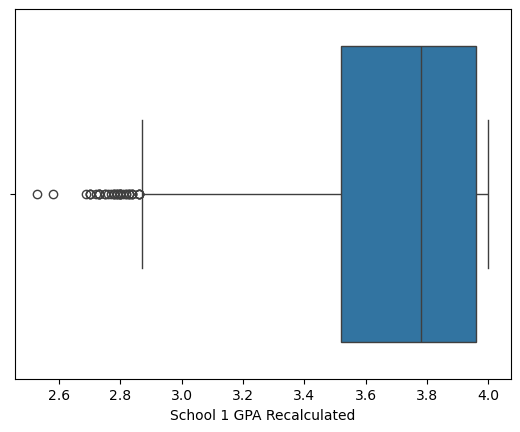

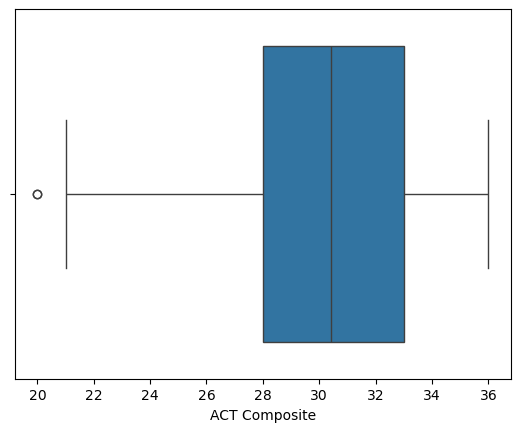

<function matplotlib.pyplot.show(close=None, block=None)>

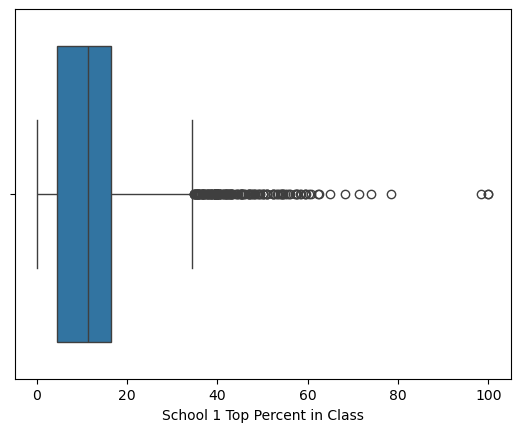

In [227]:
# check outliers
import seaborn as sns
sns.boxplot(x = 'School 1 GPA Recalculated', data = TUtest)
plt.show()

sns.boxplot(x = 'ACT Composite', data = TUtest)
plt.show()

sns.boxplot(x = 'School 1 Top Percent in Class', data = TUtest)
plt.show

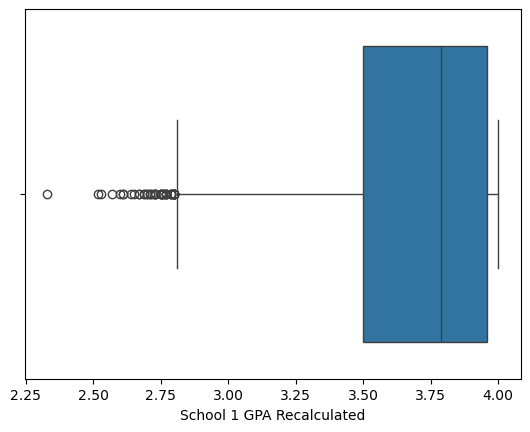

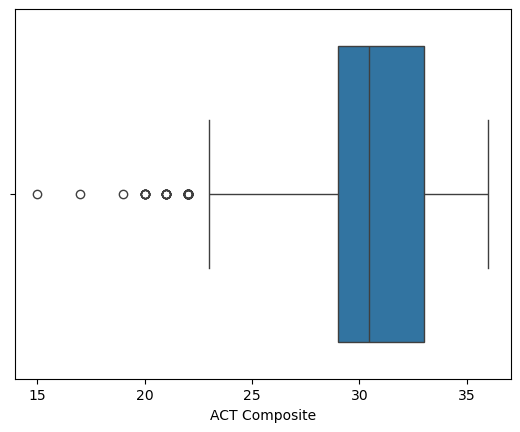

<function matplotlib.pyplot.show(close=None, block=None)>

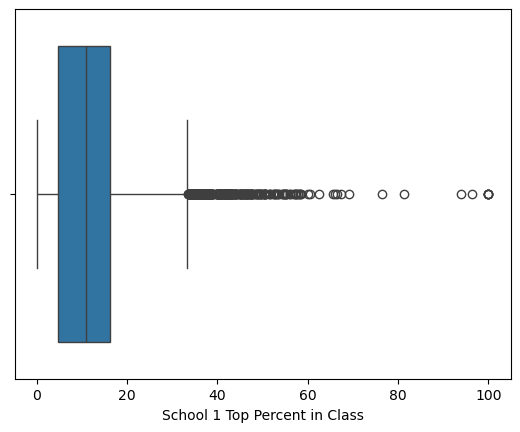

In [228]:
sns.boxplot(x = 'School 1 GPA Recalculated', data = TUtrain)
plt.show()

sns.boxplot(x = 'ACT Composite', data = TUtrain)
plt.show()

sns.boxplot(x = 'School 1 Top Percent in Class', data = TUtrain)
plt.show

In [229]:
# clean outliers using winsorization fucntion
from scipy.stats.mstats import winsorize
def winsorize_column(df, column_name, limits=(0.05, 0.05)):
    winsorized = winsorize(df[column_name], limits=limits)
    return pd.Series(winsorized, index=df.index, name=f"{column_name}_winsorized")

TUtest['School 1 GPA Recalculated'] = winsorize_column(TUtest, 'School 1 GPA Recalculated', limits = (0.01, 0))
TUtest['ACT Composite'] = winsorize_column(TUtest, 'ACT Composite', limits = (0.01, 0))
TUtest['School 1 Top Percent in Class'] = winsorize_column(TUtest, 'School 1 Top Percent in Class', limits = (0, 0.05))

TUtrain['School 1 GPA Recalculated'] = winsorize_column(TUtrain, 'School 1 GPA Recalculated', limits = (0.01, 0))
TUtrain['ACT Composite'] = winsorize_column(TUtrain, 'ACT Composite', limits = (0.01, 0))
TUtrain['School 1 Top Percent in Class'] = winsorize_column(TUtrain, 'School 1 Top Percent in Class', limits = (0, 0.04))

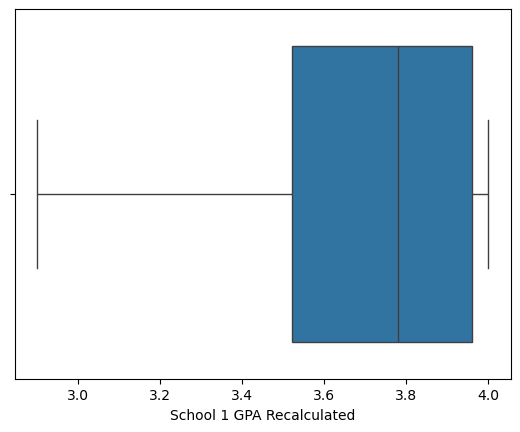

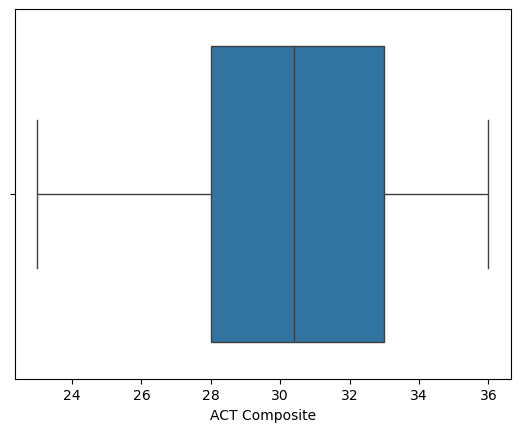

<function matplotlib.pyplot.show(close=None, block=None)>

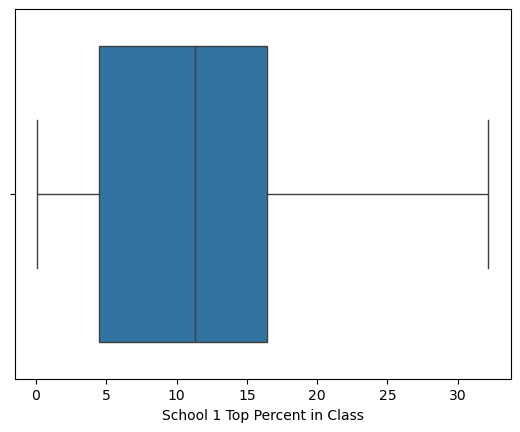

In [230]:
sns.boxplot(x = 'School 1 GPA Recalculated', data = TUtest)
plt.show()

sns.boxplot(x = 'ACT Composite', data = TUtest)
plt.show()

sns.boxplot(x = 'School 1 Top Percent in Class', data = TUtest)
plt.show

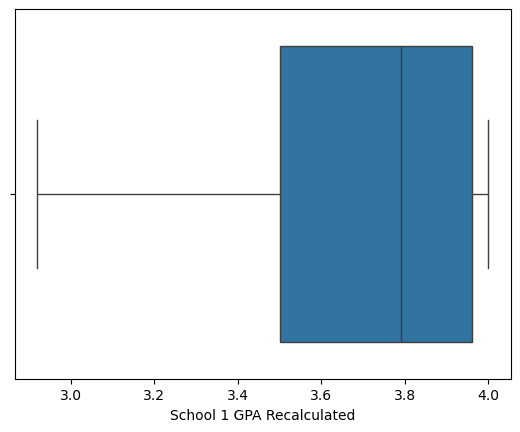

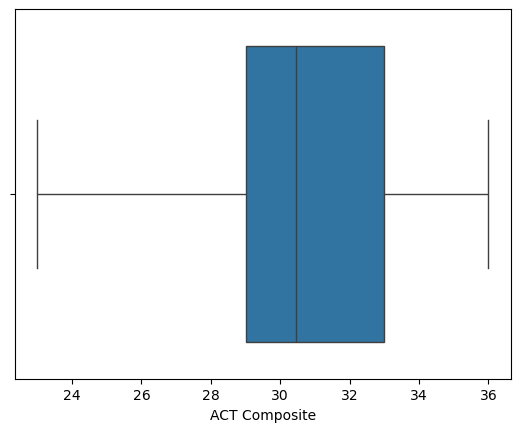

<function matplotlib.pyplot.show(close=None, block=None)>

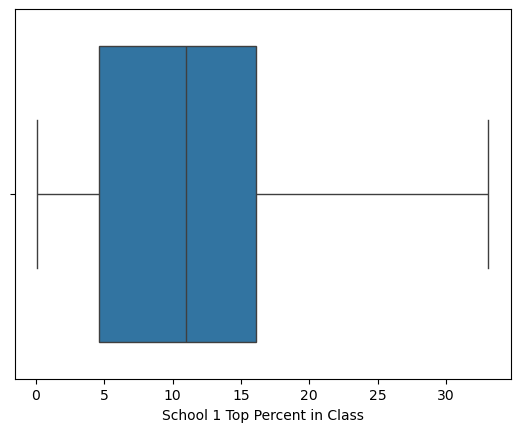

In [231]:
sns.boxplot(x = 'School 1 GPA Recalculated', data = TUtrain)
plt.show()

sns.boxplot(x = 'ACT Composite', data = TUtrain)
plt.show()

sns.boxplot(x = 'School 1 Top Percent in Class', data = TUtrain)
plt.show

In [232]:
# Feature Engineering: cuts
# TUtest
TUtest['School 1 GPA Recalculated_bin'] = pd.cut(TUtest['School 1 GPA Recalculated'], bins = [2.9, 3, 3.5, 4], labels=['<3', '3-3.5', '3.5+'])
TUtest['ACT Composite_bin'] = pd.cut(TUtest['ACT Composite'], bins = [23, 26, 29, 32, 36], labels=['<26', '26-29', '29-32', '32+'])
TUtest['School 1 Top Percent in Class_bin'] = pd.cut(TUtest['School 1 Top Percent in Class'], bins = [0, 8, 16, 24, 32, 33], 
                                                      labels=['<8', '8-16', '16-24', '24-32', '32+'])

# TUtrain
TUtrain['School 1 GPA Recalculated_bin'] = pd.cut(TUtrain['School 1 GPA Recalculated'], bins = [2.9, 3, 3.5, 4], labels=['<3', '3-3.5', '3.5+'])
TUtrain['ACT Composite_bin'] = pd.cut(TUtrain['ACT Composite'], bins = [23, 26, 29, 32, 36], labels=['<26', '26-29', '29-32', '32+'])
TUtrain['School 1 Top Percent in Class_bin'] = pd.cut(TUtest['School 1 Top Percent in Class'], bins = [0, 8, 16, 24, 32, 33], 
                                                      labels=['<8', '8-16', '16-24', '24-32', '32+'])

## Re-run the models

## Encode and Split the Data

In [235]:
# Encode the Data
# use LabelEncoder to convert object and category columns into ordinal columns
from sklearn.preprocessing import LabelEncoder
def encode(df):
    encoded_data =TUtrain.copy()
    for col in encoded_data.columns:
        if encoded_data[col].dtype == 'object' or encoded_data[col].dtype.name == 'category':
            le = LabelEncoder()
            encoded_data[col] = le.fit_transform(encoded_data[col].astype(str))
    return encoded_data

TUtrain = encode(TUtrain)

In [236]:
# Encode the Data
# use LabelEncoder to convert object and category columns into ordinal columns
from sklearn.preprocessing import LabelEncoder
def encode(df):
    encoded_data =TUtest.copy()
    for col in encoded_data.columns:
        if encoded_data[col].dtype == 'object' or encoded_data[col].dtype.name == 'category':
            le = LabelEncoder()
            encoded_data[col] = le.fit_transform(encoded_data[col].astype(str))
    return encoded_data

TUtest = encode(TUtest)

In [237]:
# Split Datasets
X_train = TUtrain.drop(columns='Decision',axis=1) 
X_test = TUtest.drop(columns='Decision',axis=1)
y_train = TUtrain['Decision']
y_test = TUtest['Decision']

## Simple Decision Tree

In [239]:
# Define a simple regression tree model
simple_tree = DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = 0)




# Fitting the model to the training data
simple_tree.fit(X_train, y_train)

# Predict using the trained model
y_train_pred_dt = simple_tree.predict(X_train)
y_test_pred_dt = simple_tree.predict(X_test)

# Evaluate the model using train
print("st_train_Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("st_train_Precision:", precision_score(y_train, y_train_pred_dt))
print("st_train_Recall:", recall_score(y_train, y_train_pred_dt))
print("st_train_F1-score:", f1_score(y_train, y_train_pred_dt))
print(f"Cohen's Kappa Score_train:",cohen_kappa_score(y_train, y_train_pred_dt))

# Evaluate the model using test
print("st_test_Accuracy:", accuracy_score(y_test, y_test_pred_dt))
print("st_test_Precision:", precision_score(y_test, y_test_pred_dt))
print("st_test_Recall:", recall_score(y_test, y_test_pred_dt))
print("st_test_F1-score:", f1_score(y_test, y_test_pred_dt))
print(f"Cohen's Kappa Score_test:", cohen_kappa_score(y_test, y_test_pred_dt))

st_train_Accuracy: 1.0
st_train_Precision: 1.0
st_train_Recall: 1.0
st_train_F1-score: 1.0
Cohen's Kappa Score_train: 1.0
st_test_Accuracy: 0.752090219716119
st_test_Precision: 0.4577634754625905
st_test_Recall: 0.4863247863247863
st_test_F1-score: 0.4716121011189391
Cohen's Kappa Score_test: 0.3098598012364232


## Pruned Decision Tree

In [241]:
# Define pruning tree model
simple_tree = DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = 0)

In [242]:
# define path
path = simple_tree.cost_complexity_pruning_path(X_train, y_train)
alphas=path['ccp_alphas']
alphas

array([0.00000000e+00, 4.91935484e-05, 4.95327103e-05, 4.95535714e-05,
       4.97767857e-05, 4.98054475e-05, 5.71428571e-05, 6.06060606e-05,
       6.34920635e-05, 6.36363636e-05, 6.37681159e-05, 6.38888889e-05,
       6.38888889e-05, 6.42857143e-05, 6.42857143e-05, 6.45161290e-05,
       6.45833333e-05, 6.48648649e-05, 6.50406504e-05, 6.51851852e-05,
       6.55462185e-05, 6.58119658e-05, 6.58227848e-05, 6.58333333e-05,
       6.59563731e-05, 6.60130719e-05, 6.60766962e-05, 6.62473795e-05,
       6.64391354e-05, 6.64646465e-05, 6.66666667e-05, 6.66666667e-05,
       6.66666667e-05, 7.50000000e-05, 7.50000000e-05, 7.50000000e-05,
       7.50000000e-05, 7.50000000e-05, 7.56756757e-05, 7.83216783e-05,
       7.87091837e-05, 8.00000000e-05, 8.00000000e-05, 8.00000000e-05,
       8.30367273e-05, 8.31299911e-05, 8.33333333e-05, 8.33333333e-05,
       8.33333333e-05, 8.33333333e-05, 8.33333333e-05, 8.46153846e-05,
       8.50840336e-05, 8.53605816e-05, 8.57142857e-05, 8.57142857e-05,
      

In [243]:
# loop over alphas
ACC_Train_simple=[]
ACC_Test_Simple=[]
for i in alphas:
    simple_tree=DecisionTreeClassifier(criterion = 'gini',
                                    max_features = X_train.shape[1],
                                    random_state = 0,
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    ccp_alpha = i)
    simple_tree.fit(X_train,y_train)
    y_train_pred=simple_tree.predict(X_train)
    y_test_pred=simple_tree.predict(X_test)
    ACC_Train_simple.append(cohen_kappa_score(y_train, y_train_pred))
    ACC_Test_Simple.append(cohen_kappa_score(y_test, y_test_pred))

In [244]:
# return max alpha
alphas[ACC_Test_Simple.index(max(ACC_Test_Simple))]

0.00034514849856026424

In [245]:
# Use the best alpha to contruct the pruned tree
pruned_tree = DecisionTreeClassifier(criterion = 'gini', 
                                    min_samples_split = 2, 
                                    min_samples_leaf = 1,
                                    max_depth = None,
                                    max_features = X_train.shape[1],
                                    random_state= 0,
                                    ccp_alpha = 0.00034514849856026424)
pruned_tree.fit(X_train, y_train)

# Predict using the trained model
y_train_pred_pt = pruned_tree.predict(X_train)
y_test_pred_pt = pruned_tree.predict(X_test)

In [246]:
# Evaluate the model using train
print("pt_train_Accuracy:", accuracy_score(y_train, y_train_pred_pt))
print("pt_train_Precision:", precision_score(y_train, y_train_pred_pt))
print("pt_train_Recall:", recall_score(y_train, y_train_pred_pt))
print("pt_train_F1-score:", f1_score(y_train, y_train_pred_pt))
print("Cohen's Kappa Score_train:", cohen_kappa_score(y_train, y_train_pred_pt))
# Evaluate the model using test
print("pt_test_Accuracy:", accuracy_score(y_test, y_test_pred_pt))
print("pt_test_recision:", precision_score(y_test, y_test_pred_pt))
print("pt_test_Recall:", recall_score(y_test, y_test_pred_pt))
print("Cohen's Kappa Score_train:", cohen_kappa_score(y_test, y_test_pred_pt))

pt_train_Accuracy: 0.8535
pt_train_Precision: 0.7340631036703155
pt_train_Recall: 0.5200729927007299
pt_train_F1-score: 0.6088117489986649
Cohen's Kappa Score_train: 0.521892556170608
pt_test_Accuracy: 0.8201438848920863
pt_test_recision: 0.6521739130434783
pt_test_Recall: 0.44871794871794873
Cohen's Kappa Score_train: 0.4250141260435898


In [247]:
# Output feature importance
pt_feature_importances = pruned_tree.feature_importances_
print(pt_feature_importances)
# Create a feature importance data frame
feature_importance_dict = {'feature_name': X_train.columns, 'pt_feature_importances': pt_feature_importances}
feature_importance_df = pd.DataFrame(feature_importance_dict).sort_values(by = 'pt_feature_importances', ascending=False)
print(feature_importance_df)

[0.00626868 0.         0.0150735  0.15970552 0.03622575 0.09669159
 0.00638228 0.00358816 0.00428501 0.00656497 0.00548538 0.38291626
 0.15699137 0.00885915 0.0411086  0.02057647 0.00969915 0.00479727
 0.00884097 0.02593992 0.         0.         0.        ]
                                feature_name  pt_feature_importances
11                 Total Event Participation                0.382916
3                              Decision Plan                0.159706
12                    Count of Campus Visits                0.156991
5                                    Athlete                0.096692
14                             ACT Composite                0.041109
4                                     Legacy                0.036226
19             School 1 Top Percent in Class                0.025940
15                       Permanent Geomarket                0.020576
2                                   Religion                0.015073
16                            Academic Index        

## Random Forest

In [249]:
# Grow a random forest. Each time you construct a simple tree for the random forest, 
#     consider six predictors as the splitting candidates for each split.
Tree_RF = RandomForestClassifier(n_estimators = 200, 
                           criterion = 'gini',
                           max_features = 6, 
                           bootstrap = True,
                           max_samples = X_train.shape[0],
                           max_depth=None,
                           random_state = 0)

In [250]:
# Write a loop to find the optimal max_features value

max_features = []
best_kappa_rf = []
for i in range(1, X_train.shape[1]+1):
    Tree_RF = RandomForestClassifier(n_estimators = 100, 
                                    criterion = 'gini',
                                    max_features = i, 
                                    bootstrap = True,
                                    max_samples = X_train.shape[0],
                                    max_depth=None,
                                    random_state = 0)
    Tree_RF.fit(X_train, y_train)
    y_test_pred=Tree_RF.predict(X_test)
    max_features.append(i)
    best_kappa_rf.append(cohen_kappa_score(y_test, y_test_pred))

# Create a data frame to store max_features and subtest_mse_rf and sort the data frame by subtest_mae_rf.
df_mae_rf = pd.DataFrame({'max_features': max_features, 'best_kappa_rf': best_kappa_rf}).sort_values(by = 'best_kappa_rf',ascending=False)
print(df_mae_rf)

    max_features  best_kappa_rf
5              6       0.468919
11            12       0.460120
6              7       0.459679
10            11       0.457819
12            13       0.455071
8              9       0.453082
7              8       0.451417
13            14       0.451329
9             10       0.450546
4              5       0.450382
14            15       0.449995
19            20       0.448407
20            21       0.447435
15            16       0.447009
21            22       0.444038
3              4       0.443369
22            23       0.440289
17            18       0.440228
18            19       0.439127
16            17       0.437608
2              3       0.428114
1              2       0.390362
0              1       0.295979


In [251]:
# Use the optimal max_features to grow a random forest
Tree_RF_Best = RandomForestClassifier(n_estimators = 100, 
                           criterion = 'gini',
                           max_features = 6, 
                           bootstrap = True,
                           max_samples = X_train.shape[0],
                           max_depth=None,
                           random_state = 0)

Tree_RF_Best.fit(X_train, y_train)

# Predict using the fitted model

y_train_pred_RF = Tree_RF_Best.predict(X_train)
y_test_pred_RF = Tree_RF_Best.predict(X_test)

In [252]:
# Evaluate the model using train
print("RF_train_Accuracy:", accuracy_score(y_train, y_train_pred_RF))
print("RF_train_Precision:", precision_score(y_train, y_train_pred_RF))
print("RF_train_Recall:", recall_score(y_train, y_train_pred_RF))
print("RF_train_F1-score:", f1_score(y_train, y_train_pred_RF))
print("Cohen's Kappa Score_train:",cohen_kappa_score(y_train, y_train_pred_RF))

# Evaluate the model using test
print("RF_test_Accuracy:", accuracy_score(y_test, y_test_pred_RF))
print("RF_test_Precision:", precision_score(y_test, y_test_pred_RF))
print("RF_test_Recall:", recall_score(y_test, y_test_pred_RF))
print("RF_test_F1-score:", f1_score(y_test, y_test_pred_RF))
print("Cohen's Kappa Score_test:", cohen_kappa_score(y_test, y_test_pred_RF))

RF_train_Accuracy: 1.0
RF_train_Precision: 1.0
RF_train_Recall: 1.0
RF_train_F1-score: 1.0
Cohen's Kappa Score_train: 1.0
RF_test_Accuracy: 0.8329768617538402
RF_test_Precision: 0.6894031668696712
RF_test_Recall: 0.48376068376068376
RF_test_F1-score: 0.5685585133098945
Cohen's Kappa Score_test: 0.468918887890988
